<a href="https://colab.research.google.com/github/dr-koehler-ai/ICU-Mortality-Prediction/blob/main/Early_ICU_Mortality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICU Mortality Prediction
### From exploratory analysis to a first model comparison

**Learning project · WiDS Datathon 2020 · Binary classification**

> Can clinical information recorded during the first day of an ICU stay help distinguish patients who die in hospital from those who survive?

This notebook follows a simple workflow: understanding the data, preparing features, comparing three classifiers against a dummy baseline, and interpreting the results.

**Prediction target:** `hospital_death` (0 = survived; 1 = died in hospital). This is hospital mortality, not ICU mortality alone.

## At a glance

| Dataset | Development split | Evaluation |
|---|---|---|
| 91,713 encounters; 186 columns including target and identifiers | 80% training / 20% test, stratified | Five-fold stratified cross-validation within training data |

### Recorded results from the supplied notebook

| Model | CV ROC-AUC | CV average precision | Test ROC-AUC |
|---|---:|---:|---:|
| Dummy | 0.500 | 0.086 | Not evaluated |
| Logistic regression | 0.841 | 0.424 | 0.850 |
| Random forest | 0.863 | 0.455 | 0.867 |
| XGBoost | 0.872 | 0.497 | 0.879 |


## Contents

1. Setup and data audit
2. Split, missingness and outcome
3. Exploratory analysis and statistics
4. Preprocessing and model evaluation
5. Model comparison and limitations


In [1]:
# Early ICU Mortality Prediction
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Data modeling
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

# Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone


# =========================
# 1. Dataset Download
# =========================

from google.colab import drive
drive.mount("/content/drive")

dataset_path = Path("/content/drive/MyDrive/AI_Healthcare/ICU_Mortality_Prediction/training_v2.csv")

data = pd.read_csv(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Dataset overview

The file contains 91,713 rows and 186 columns, including identifiers, the target and candidate predictors. The audit below checks IDs, missingness and constant columns.


In [2]:
print("\nShape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nPatients:", data["patient_id"].nunique())


Shape: (91713, 186)

Columns: ['encounter_id', 'patient_id', 'hospital_id', 'hospital_death', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_mi

In [3]:
audit = pd.DataFrame({
    "dtype": data.dtypes,
    "missing_n": data.isna().sum(),
    "missing_pct": data.isna().mean().mul(100),
    "n_unique": data.nunique()
})

display(audit.loc[
    ["encounter_id", "patient_id", "hospital_id", "hospital_death"]
])

print("Duplicate encounter IDs:", data["encounter_id"].duplicated().sum())
print("Duplicate patient IDs:", data["patient_id"].duplicated().sum())
print("Target values, including missing values:")
print(data["hospital_death"].value_counts(dropna=False))

display(audit.loc[audit["n_unique"] <= 1])

,dtype,missing_n,missing_pct,n_unique
encounter_id,int64,0,0.0,91713
patient_id,int64,0,0.0,91713
hospital_id,int64,0,0.0,147
hospital_death,int64,0,0.0,2


Duplicate encounter IDs: 0
Duplicate patient IDs: 0
Target values, including missing values:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


,dtype,missing_n,missing_pct,n_unique
readmission_status,int64,0,0.0,1


## 2. Training/test split and missingness

The split is fixed with `random_state=42`. Subsequent EDA uses training data. Earlier project exploration included the full dataset, so the test set was not completely unseen throughout development.

In [4]:
train_data, test_data = train_test_split(
    data,
    test_size=0.20,
    stratify=data["hospital_death"],
    random_state=42
)

eda_vars = [
    "age",
    "d1_heartrate_max",
    "d1_mbp_min",
    "d1_spo2_min",
    "d1_creatinine_max",
    "d1_lactate_max"
]

missing_summary = pd.DataFrame({
    "available_n": train_data[eda_vars].notna().sum(),
    "missing_pct": train_data[eda_vars].isna().mean() * 100
})

display(
    missing_summary.sort_values("missing_pct", ascending=False).round(1)
)

missing_by_outcome = (
    train_data[eda_vars]
    .isna()
    .groupby(train_data["hospital_death"])
    .mean()
    .mul(100)
    .T
)

missing_by_outcome.columns = [
    "missing_survived_pct",
    "missing_died_pct"
]

display(missing_by_outcome.round(1))

,available_n,missing_pct
d1_lactate_max,18724,74.5
d1_creatinine_max,65255,11.1
age,69926,4.7
d1_spo2_min,73101,0.4
d1_mbp_min,73195,0.2
d1_heartrate_max,73251,0.2


,missing_survived_pct,missing_died_pct
age,4.3,8.4
d1_heartrate_max,0.2,0.2
d1_mbp_min,0.2,0.3
d1_spo2_min,0.3,0.6
d1_creatinine_max,11.1,10.6
d1_lactate_max,76.9,49.1


### Missingness and checking for duplicates

In [5]:
# =========================
# Missing Data Analysis
# =========================

missing = train_data.isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(50))

print(train_data.duplicated().sum())
print("There are no duplicates")


Top Missing Values:
 h1_bilirubin_min          0.922829
h1_bilirubin_max          0.922829
h1_lactate_min            0.919899
h1_lactate_max            0.919899
h1_albumin_max            0.913970
h1_albumin_min            0.913970
h1_pao2fio2ratio_min      0.874663
h1_pao2fio2ratio_max      0.874663
h1_arterial_ph_max        0.834197
h1_arterial_ph_min        0.834197
h1_hco3_max               0.829440
h1_hco3_min               0.829440
h1_arterial_pco2_max      0.829140
h1_arterial_pco2_min      0.829140
h1_arterial_po2_min       0.829031
h1_arterial_po2_max       0.829031
h1_wbc_max                0.828786
h1_wbc_min                0.828786
h1_calcium_max            0.827259
h1_calcium_min            0.827259
h1_platelets_min          0.825787
h1_platelets_max          0.825787
h1_bun_max                0.818591
h1_bun_min                0.818591
h1_diasbp_invasive_max    0.817882
h1_diasbp_invasive_min    0.817882
h1_sysbp_invasive_max     0.817746
h1_sysbp_invasive_min     0.81774

### Analysis of Target Variable


*   With a mortality rate of 8,6%, 7915 of the 91713 patients died in-hospital. Thus, we deal with a highly imbalanced dataset.  The output below describes the training subset.



Outcome distribution:
hospital_death
0    67038
1     6332
Name: count, dtype: int64
Mortality rate: 8.6%


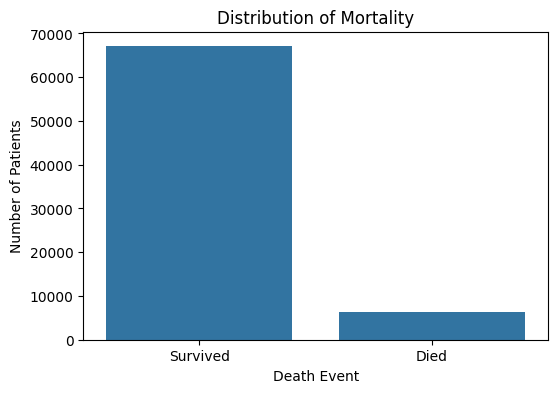

In [6]:
# =========================
# Target Variable
# =========================

print("Outcome distribution:")
print(train_data["hospital_death"].value_counts())
mortality_rate = train_data["hospital_death"].mean()

print(f"Mortality rate: {mortality_rate:.1%}")
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_data,
    x="hospital_death"
)

plt.title("Distribution of Mortality")
plt.xlabel("Death Event")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Survived", "Died"])
plt.show()

## 3. Exploratory data analysis

The main plots focus on six variables.

The selected feature set combines demographics, binary clinical indicators and first-day measurements. APACHE-related fields and precomputed mortality probabilities are not included in this baseline; not every APACHE-related field is itself a score.


In [7]:
data.columns.to_list()

demographic_vars = ['age',
 'bmi']

clinical_vars = ['gender',
 'ethnicity',
 'elective_surgery',
 'aids',
 'cirrhosis',
 'diabetes_mellitus',
 'hepatic_failure',
 'immunosuppression',
 'leukemia',
 'lymphoma',
 'solid_tumor_with_metastasis']

apache_vars = [
 'albumin_apache',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bilirubin_apache',
 'bun_apache',
 'creatinine_apache',
 'fio2_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'paco2_apache',
 'paco2_for_ph_apache',
 'pao2_apache',
 'ph_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'urineoutput_apache',
 'ventilated_apache',
 'wbc_apache']

d1_vars = [
 'd1_heartrate_max',
 'd1_heartrate_min',
 'd1_mbp_max',
 'd1_mbp_min',
 'd1_resprate_max',
 'd1_resprate_min',
 'd1_spo2_min',
 'd1_sysbp_max',
 'd1_sysbp_min',
 'd1_temp_max',
 'd1_temp_min',
 'd1_albumin_min',
 'd1_bilirubin_max',
 'd1_bun_max',
 'd1_calcium_max',
 'd1_calcium_min',
 'd1_creatinine_max',
 'd1_glucose_max',
 'd1_glucose_min',
 'd1_hco3_max',
 'd1_hco3_min',
 'd1_hemaglobin_max',
 'd1_hemaglobin_min',
 'd1_inr_max',
 'd1_lactate_max',
 'd1_platelets_max',
 'd1_platelets_min',
 'd1_potassium_max',
 'd1_potassium_min',
 'd1_sodium_max',
 'd1_sodium_min',
 'd1_wbc_max',
 'd1_wbc_min',
 'd1_arterial_pco2_max',
 'd1_arterial_ph_min',
 'd1_arterial_po2_min',
 'd1_pao2fio2ratio_min']

missing = train_data[d1_vars].isnull().mean().sort_values(ascending=False)
print("\nTop Missing Values:\n", missing.head(50))

variable_labels = {
    "age": "Age (Years)",
    "bmi": "BMI (kilograms/metres^2)",
    "ethnicity": "Ethnicity",
    "gender": "Gender",
    "elective_surgery": "Elective Surgery",
    "aids": "AIDS",
    "cirrhosis": "Cirrhosis",
    "diabetes_mellitus": "Diabetes Mellitus",
    "hepatic_failure": "Hepatic Failure",
    "immunosuppression": "Immunosuppression",
    "leukemia": "Leukemia",
    "lymphoma": "Lymphoma",
    "solid_tumor_with_metastasis": "Solid Tumor with Metastasis",
    "d1_heartrate_max": "Maximum Heartrate (bpm)",
    "d1_heartrate_min": "Minimum Heartrate (bpm)",
    "d1_mbp_max": "Maximum Mean Blood Pressure (mmHg)",
    "d1_mbp_min": "Minimum Mean Blood Pressure (mmHg)",
    "d1_resprate_max": "Maximum Respiratory Rate (breaths/min)",
    "d1_resprate_min": "Minimum Respiratory Rate (breaths/min)",
    "d1_spo2_min": "Minimum Blood Oxygen Saturation (%)",
    "d1_sysbp_max": "Maximum Systolic Blood Pressure (mmHg)",
    "d1_sysbp_min": "Minimum Systolic Blood Pressure (mmHg)",
    "d1_temp_max": "Maximum Temperature (°C)",
    "d1_temp_min": "Minimum Temperature (°C)",
    "d1_albumin_min": "Minimum Albumin (g/L)",
    "d1_bilirubin_max": "Maximum Bilirubin (µmol/l)",
    "d1_bun_max": "Urea Nitrogen (mmol/l)",
    "d1_calcium_max": "Maximum Calcium (mmol/l)",
    "d1_calcium_min": "Minimum Calcium (mmol/l)",
    "d1_creatinine_max": "Maximum Creatinine (µmol/l)",
    "d1_glucose_max": "Maximum Glucose (mmol/l)",
    "d1_glucose_min": "Minimum Glucose (mmol/l)",
    "d1_hco3_max": "Maximum Bicarbonat (mmol/l)",
    "d1_hco3_min": "Minimum Bicarbonat (mmol/l)",
    "d1_hemaglobin_max": "Maximum Hemoglobin (g/dl)",
    "d1_hemaglobin_min": "Minimum Hemoglobin (g/dl)",
    "d1_inr_max": "Maximum INR",
    "d1_lactate_max": "Maximum Lactate (mmol/l)",
    "d1_platelets_max": "Maximum Platelets (×10^9/L)",
    "d1_platelets_min": "Minimum Platelets (×10^9/L)",
    "d1_potassium_max": "Maximum Potassium (mmol/l)",
    "d1_potassium_min": "Minimum Potassium (mmol/l)",
    "d1_sodium_max": "Maximum Sodium (mmol/l)",
    "d1_sodium_min": "Minimum Sodium (mmol/l)",
    "d1_wbc_max": "Maximum White Blood Cell Count (×10^9/L)",
    "d1_wbc_min": "Minimum White Blood Cell Count (×10^9/L)",
    "d1_arterial_pco2_max": "Maximum Arterial PCO2 (mmHg)",
    "d1_arterial_ph_min": "Minimum Arterial pH",
    "d1_arterial_po2_min": "Minimum Arterial PO2 (mmHg)",
    "d1_pao2fio2ratio_min": "Minimum PaO2/FiO2 Ratio"
}


Top Missing Values:
 d1_lactate_max          0.744800
d1_pao2fio2ratio_min    0.719286
d1_arterial_ph_min      0.655431
d1_arterial_pco2_max    0.646218
d1_arterial_po2_min     0.646150
d1_inr_max              0.631307
d1_bilirubin_max        0.584708
d1_albumin_min          0.534551
d1_hco3_min             0.164113
d1_hco3_max             0.164113
d1_platelets_max        0.147254
d1_platelets_min        0.147254
d1_wbc_min              0.144378
d1_wbc_max              0.144378
d1_calcium_min          0.142333
d1_calcium_max          0.142333
d1_hemaglobin_min       0.132902
d1_hemaglobin_max       0.132902
d1_bun_max              0.114461
d1_sodium_min           0.110945
d1_sodium_max           0.110945
d1_creatinine_max       0.110604
d1_potassium_min        0.104389
d1_potassium_max        0.104389
d1_glucose_max          0.063023
d1_glucose_min          0.063023
d1_temp_max             0.025201
d1_temp_min             0.025201
d1_resprate_max         0.004361
d1_resprate_min      

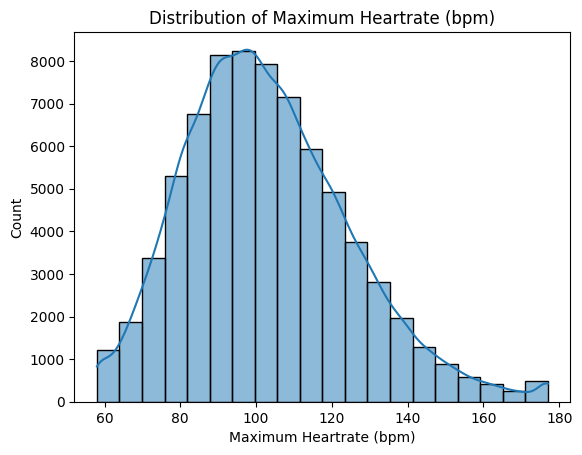

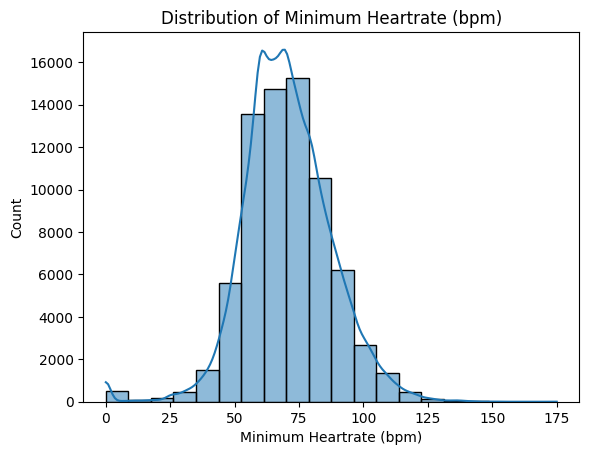

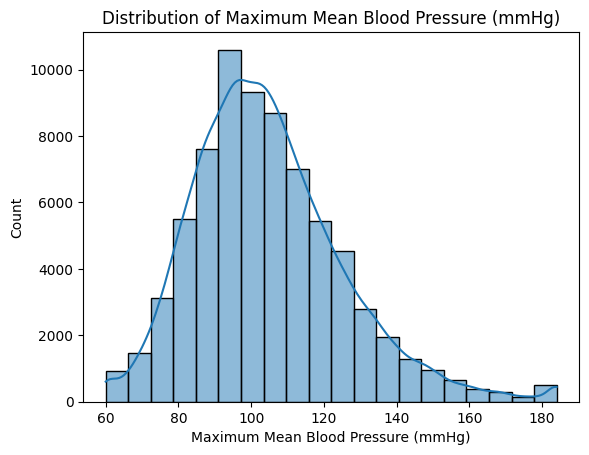

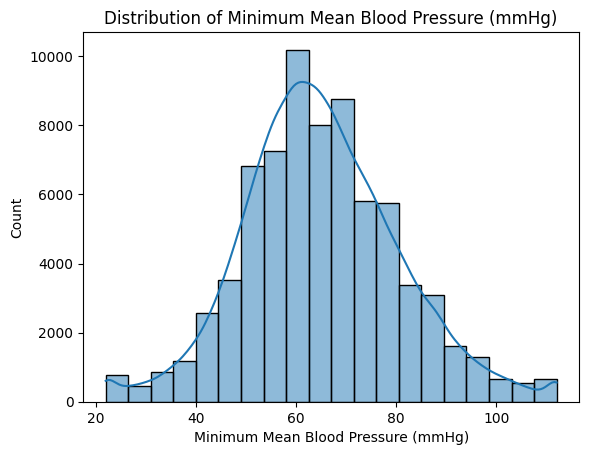

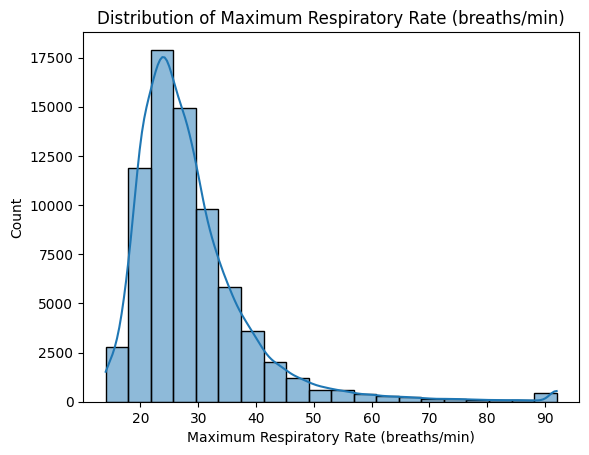

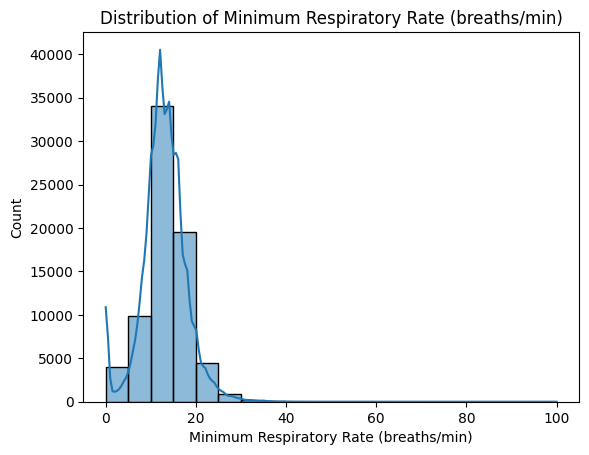

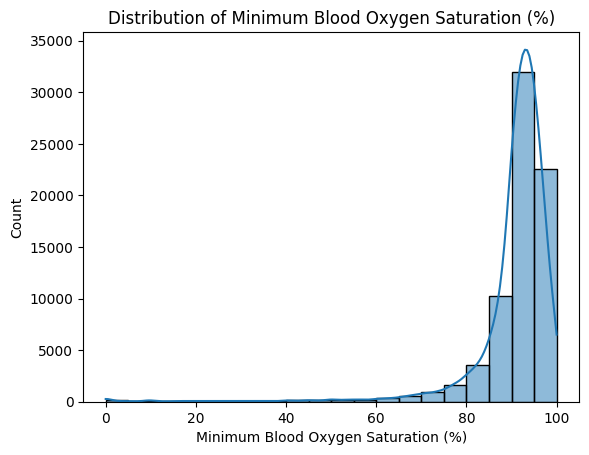

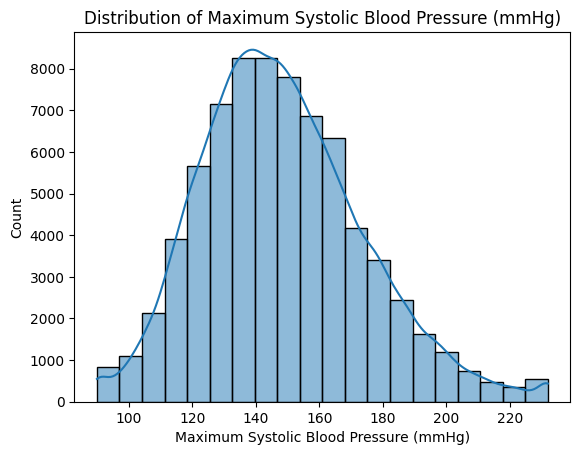

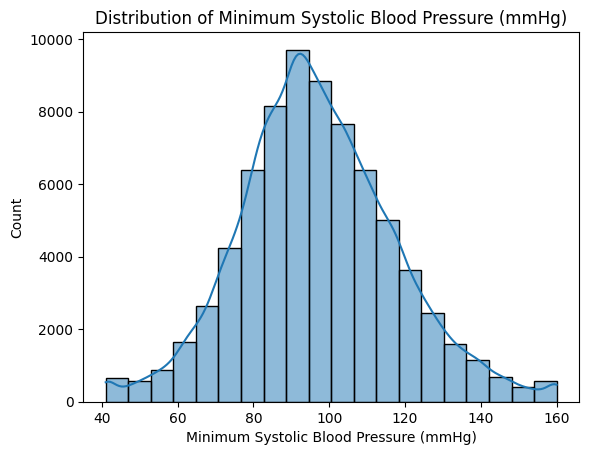

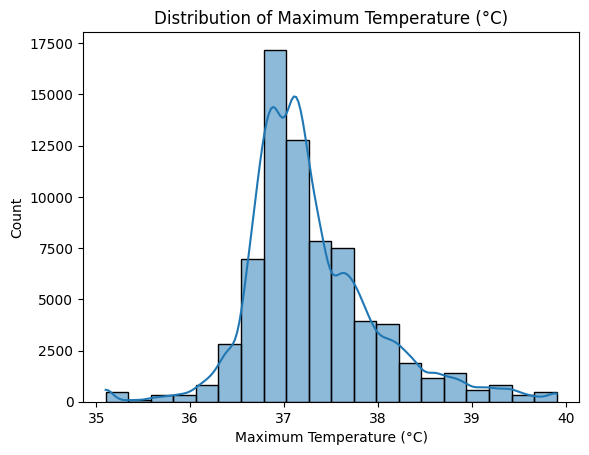

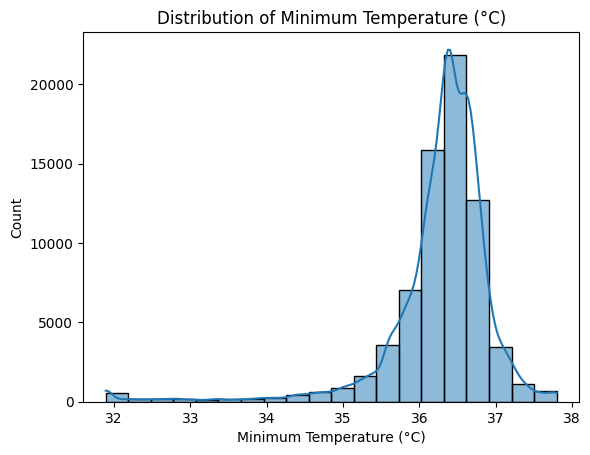

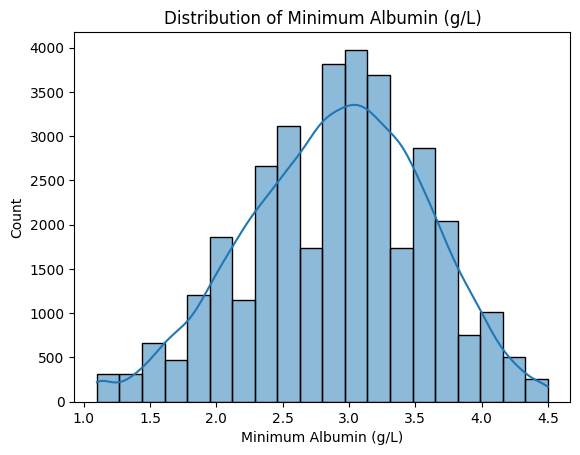

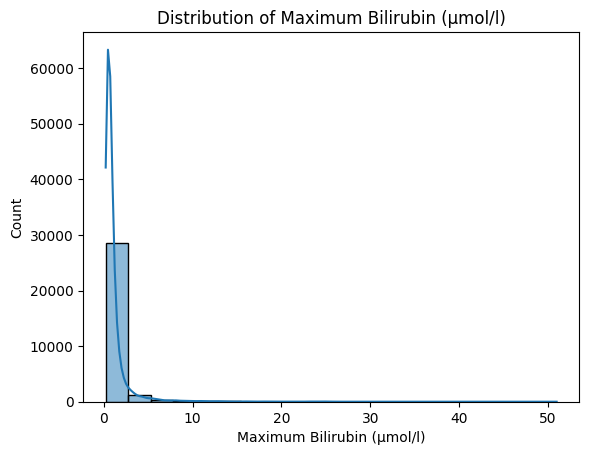

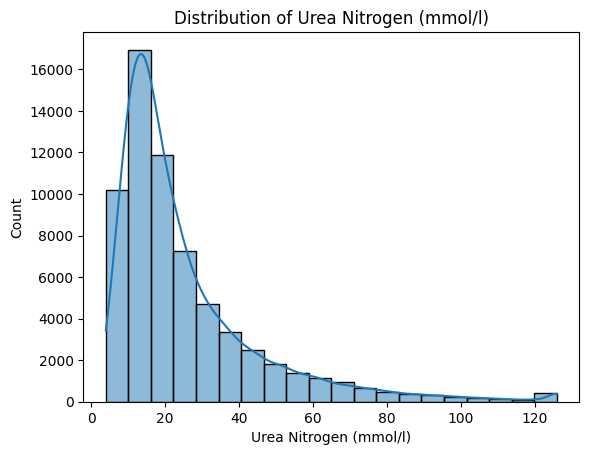

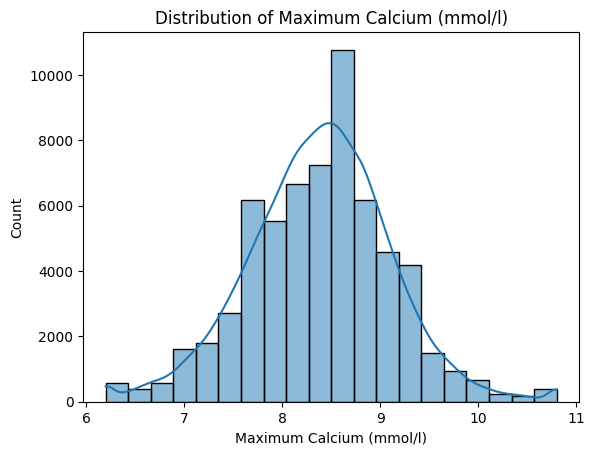

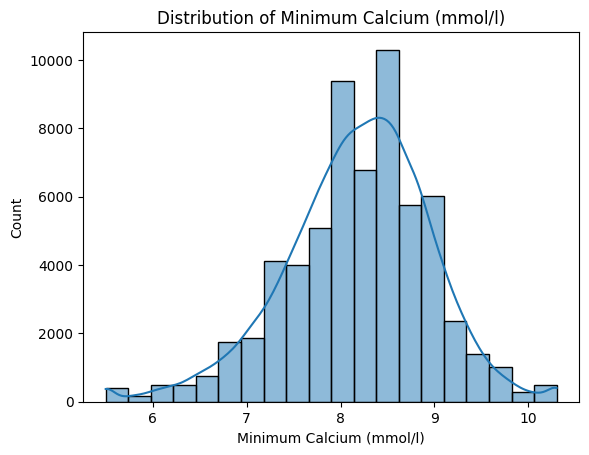

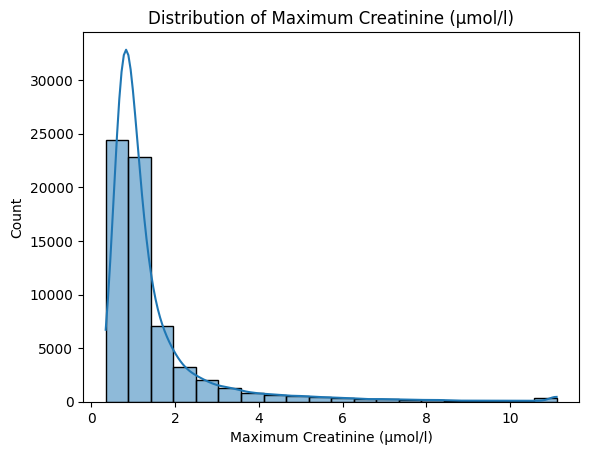

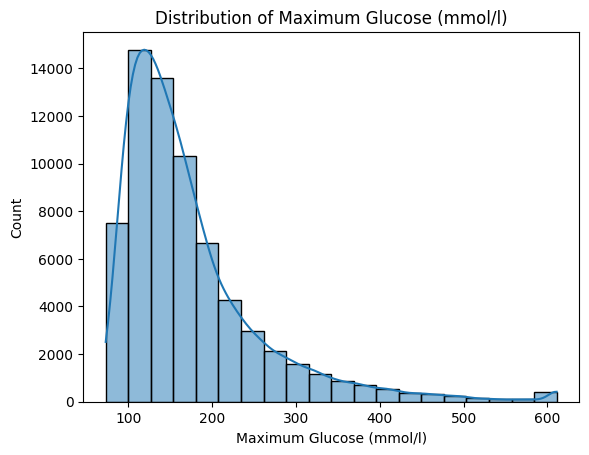

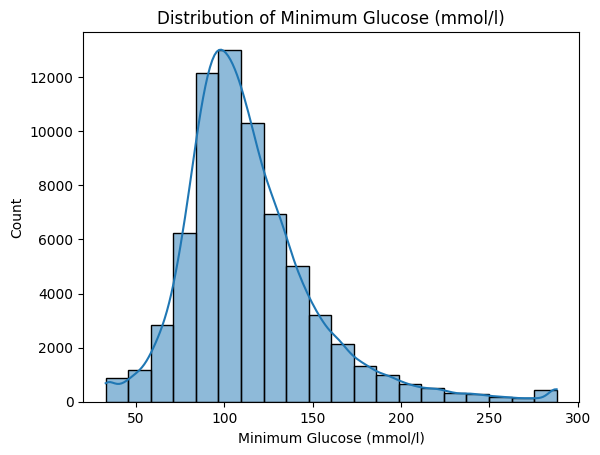

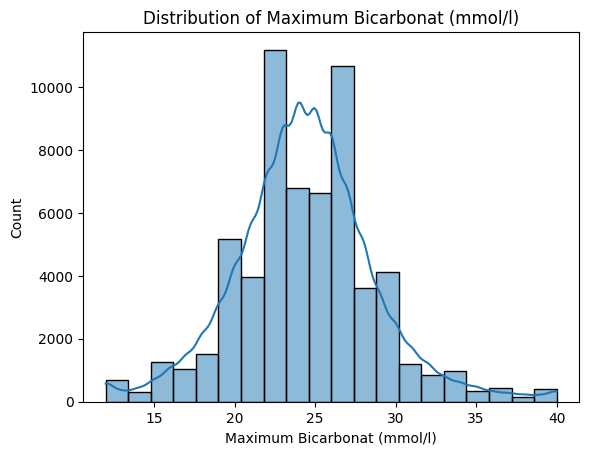

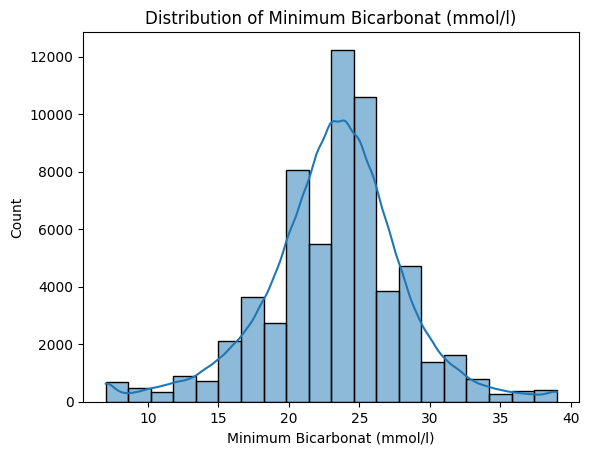

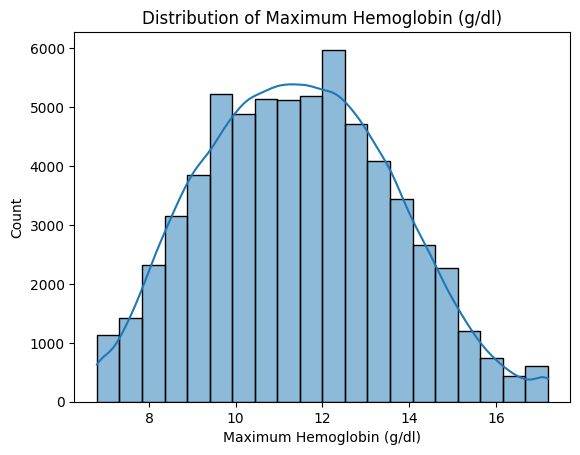

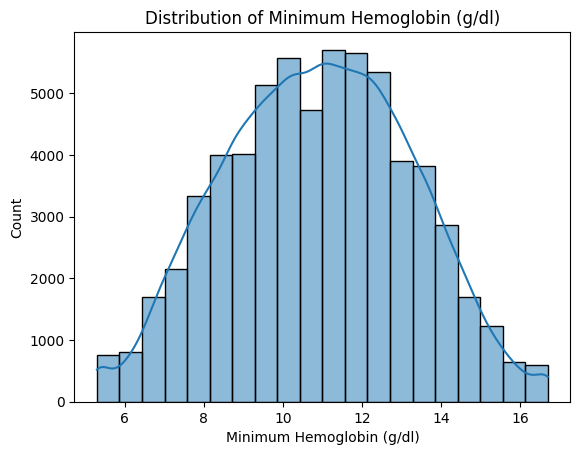

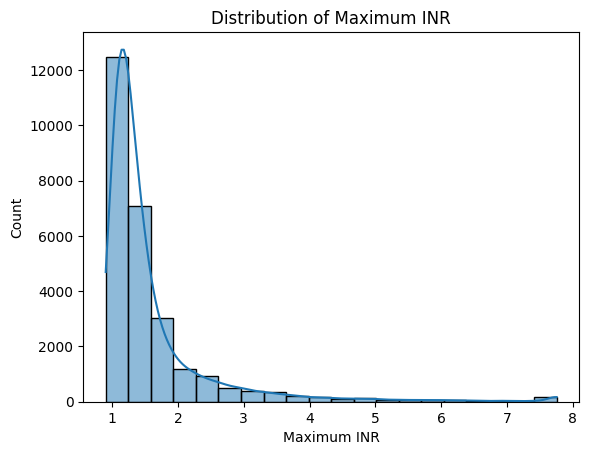

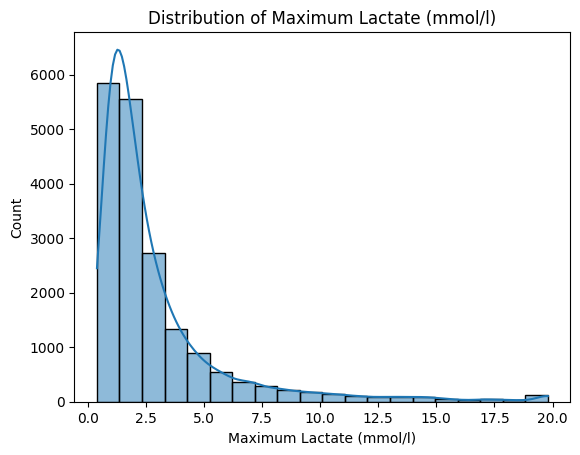

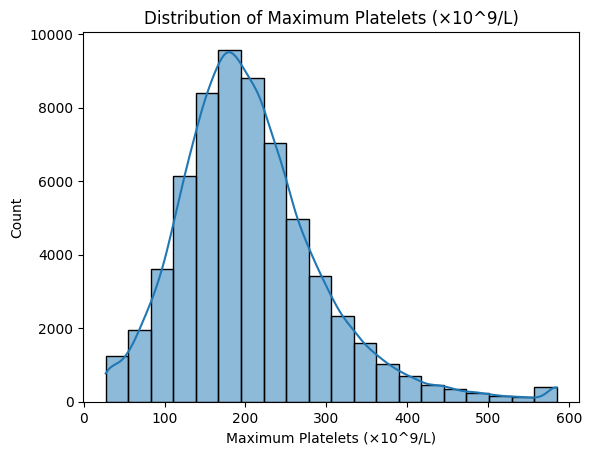

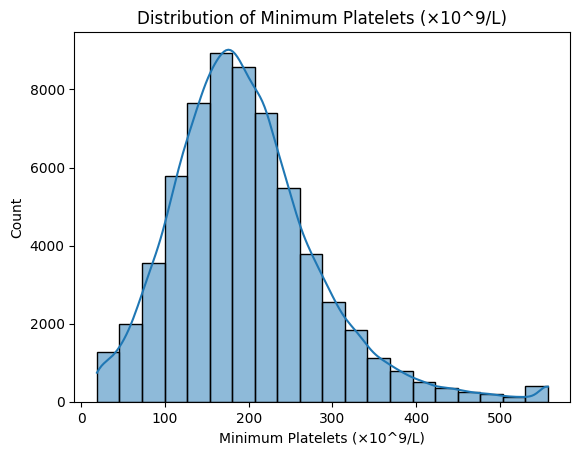

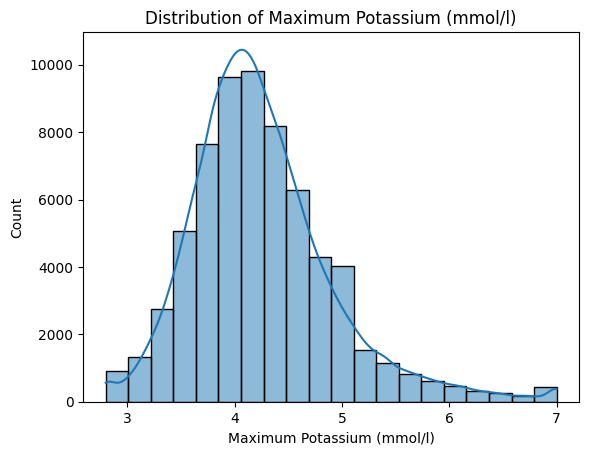

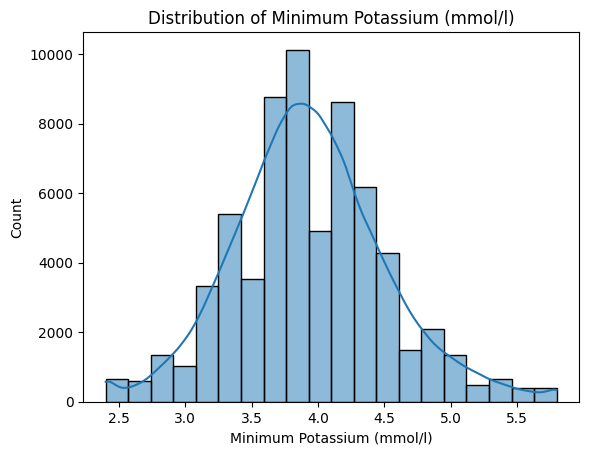

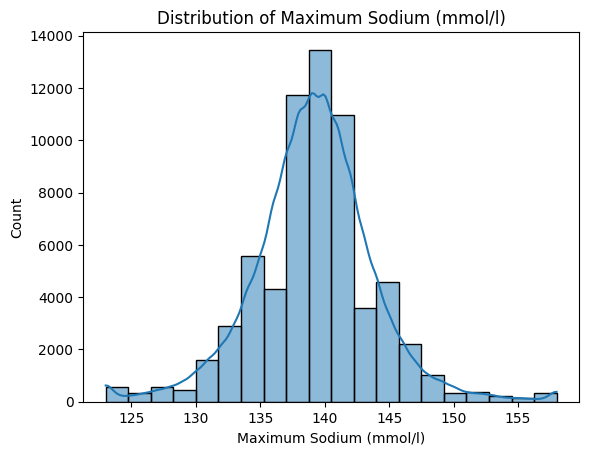

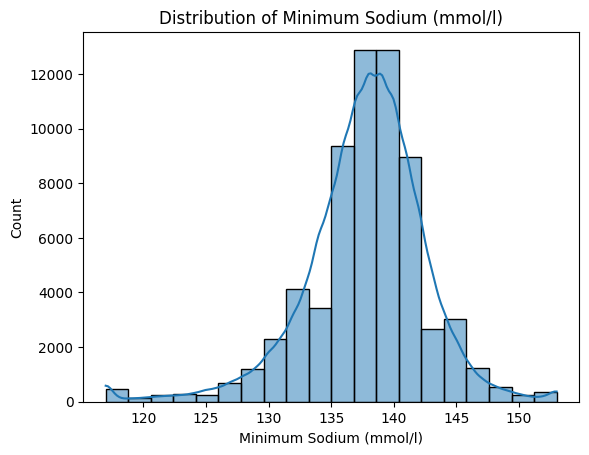

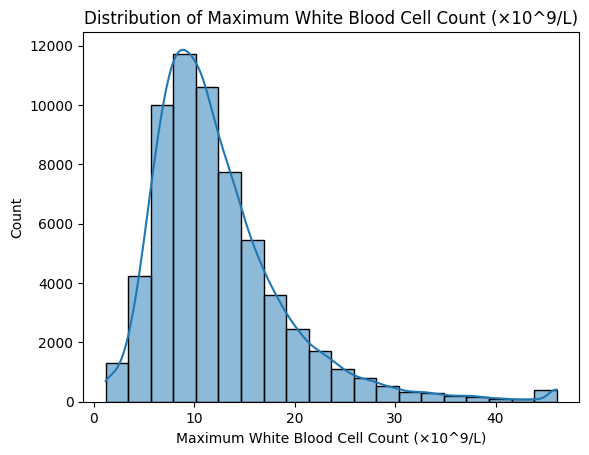

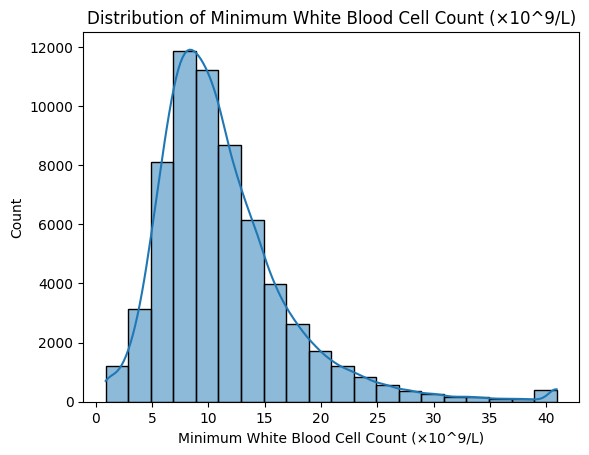

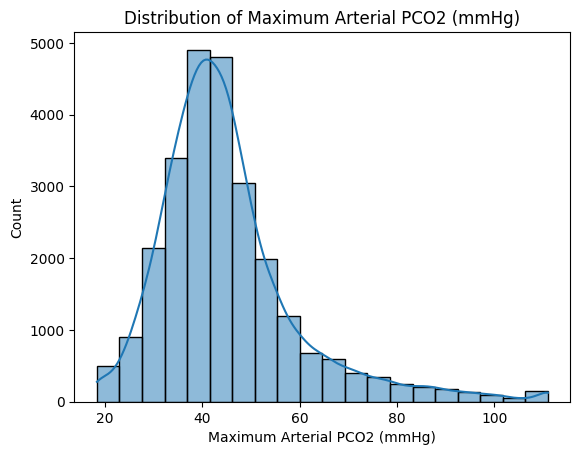

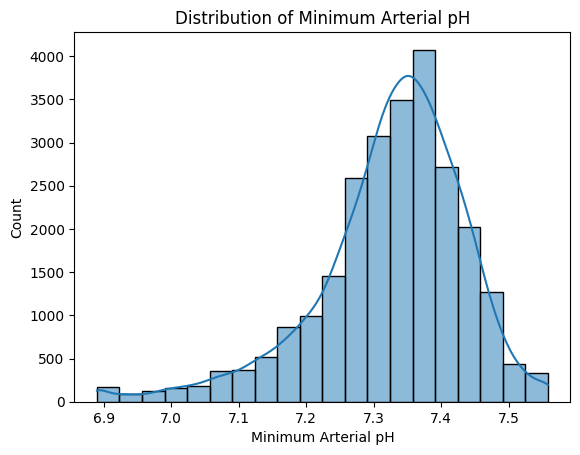

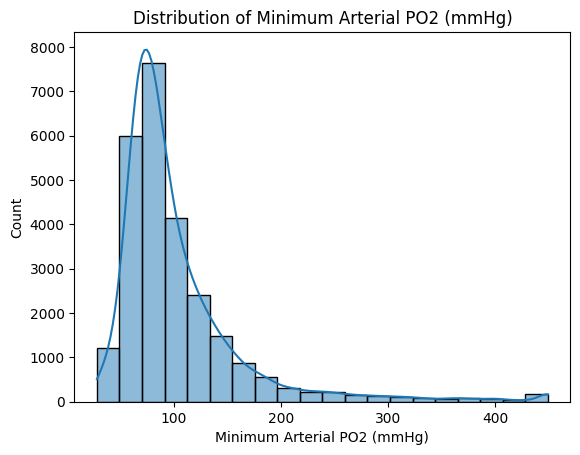

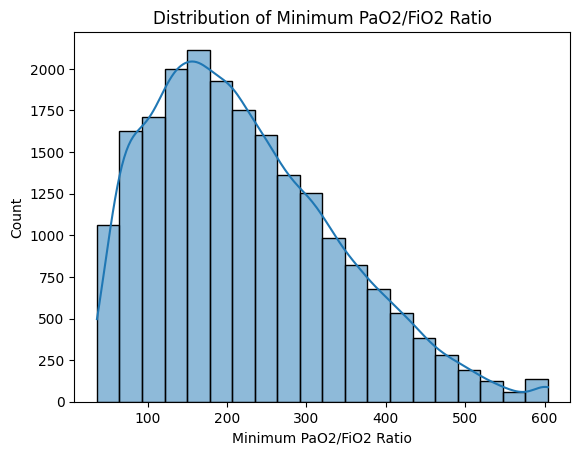

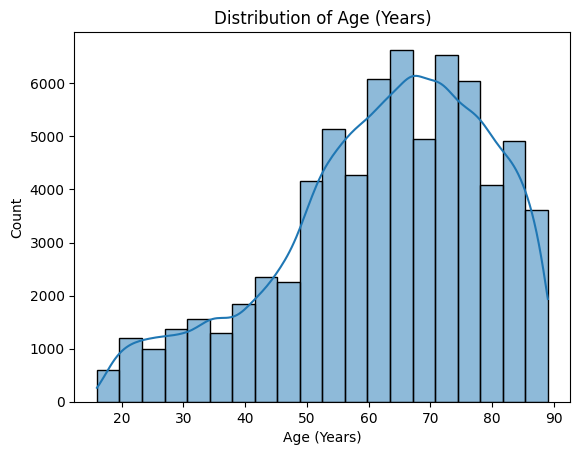

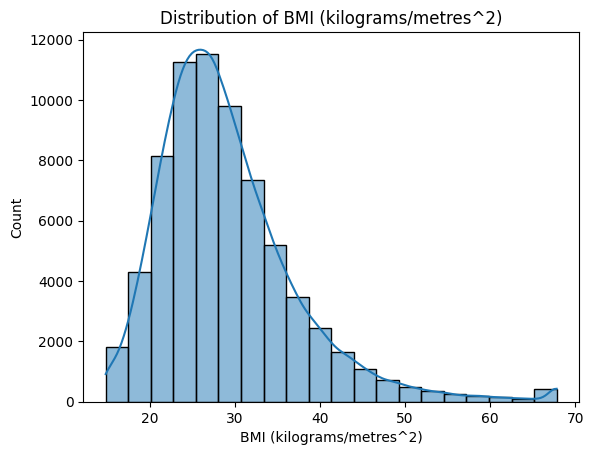

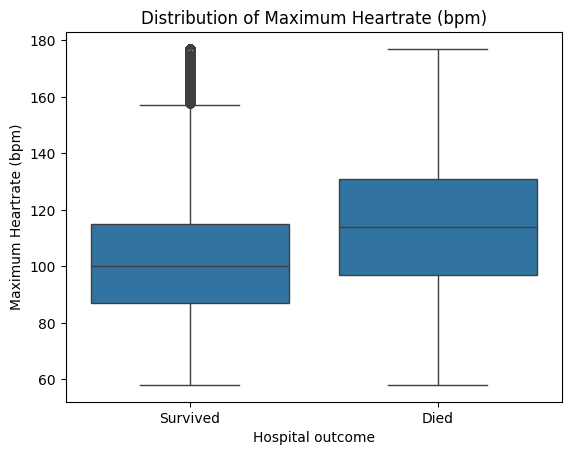

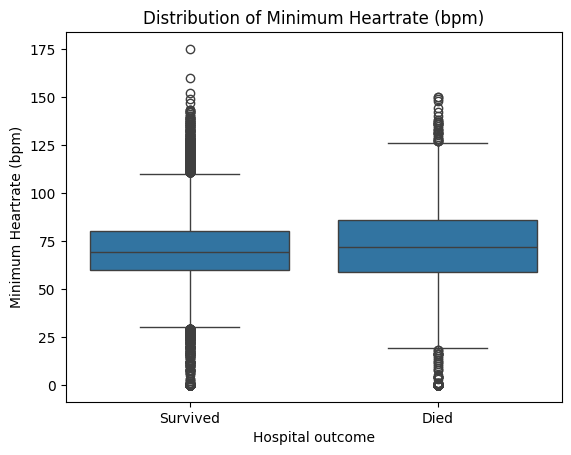

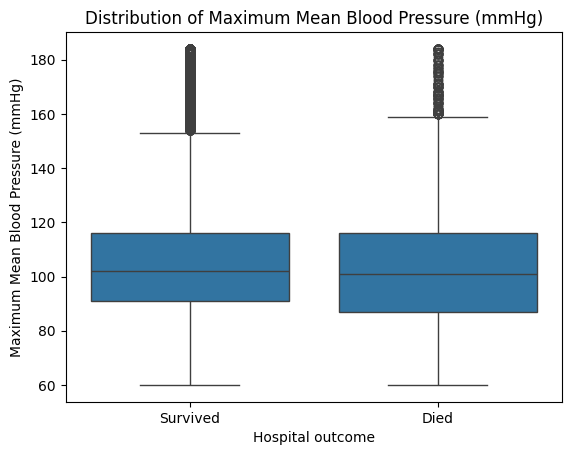

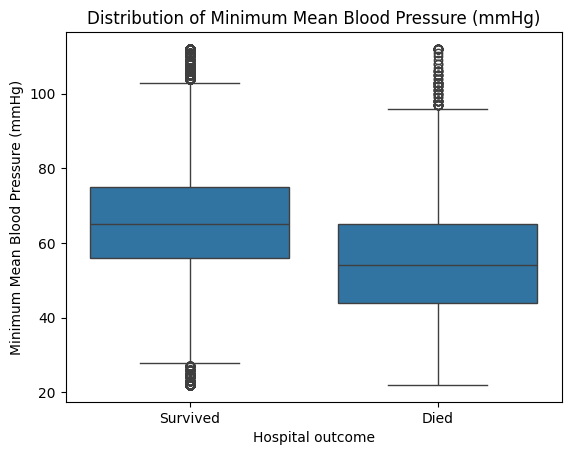

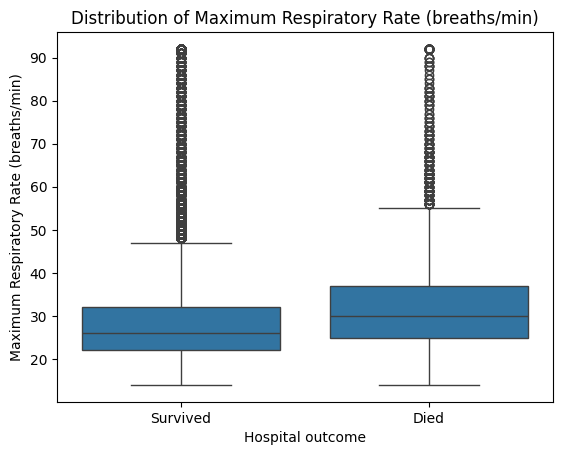

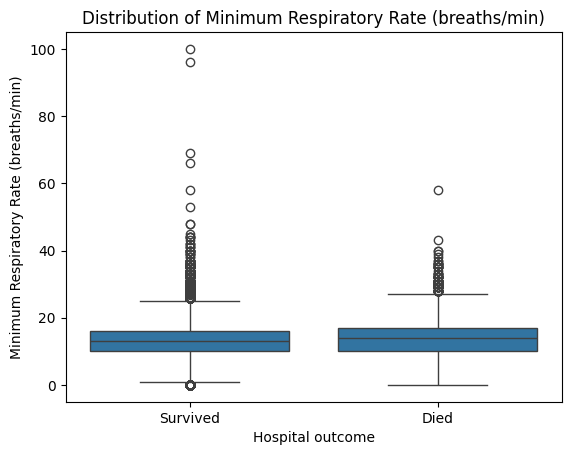

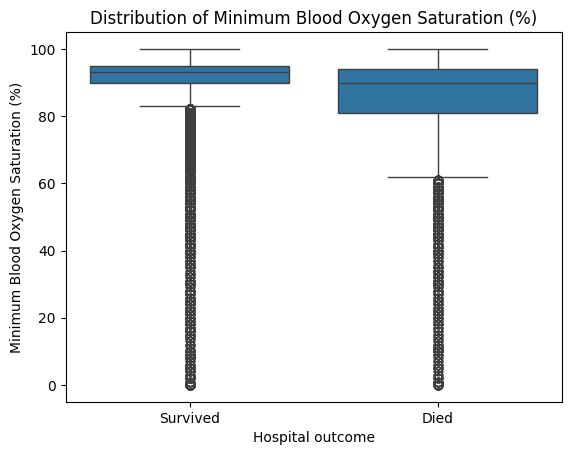

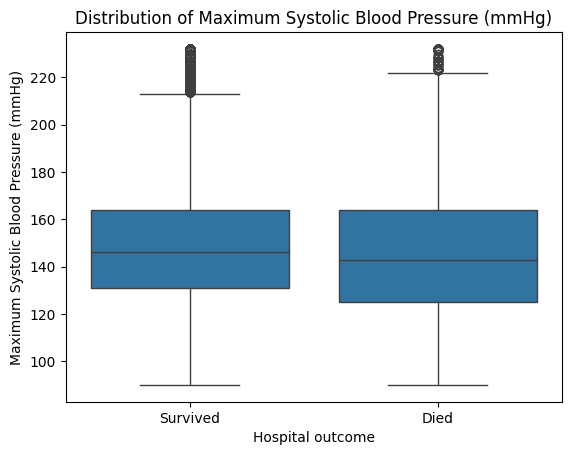

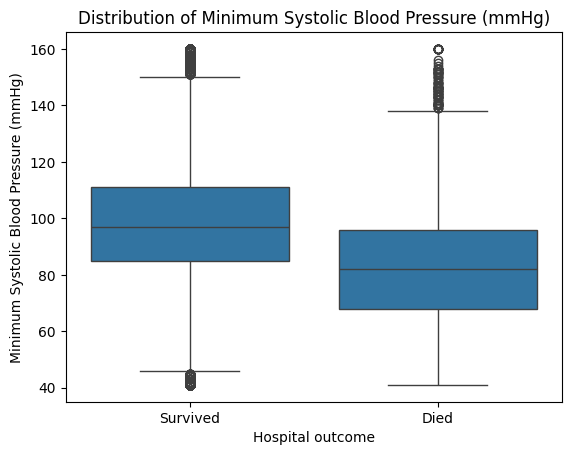

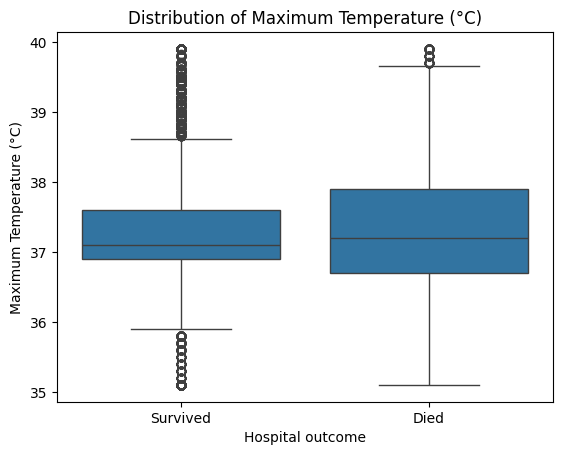

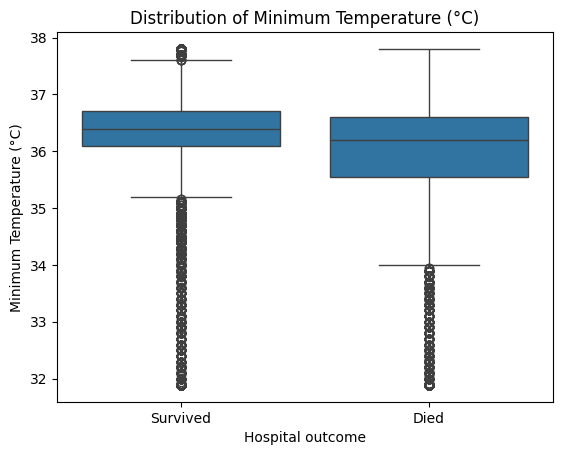

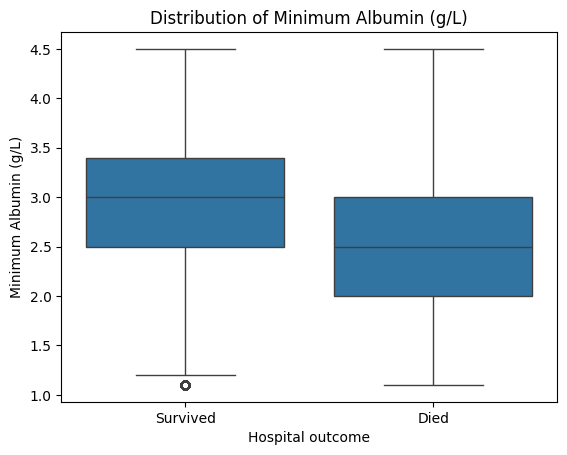

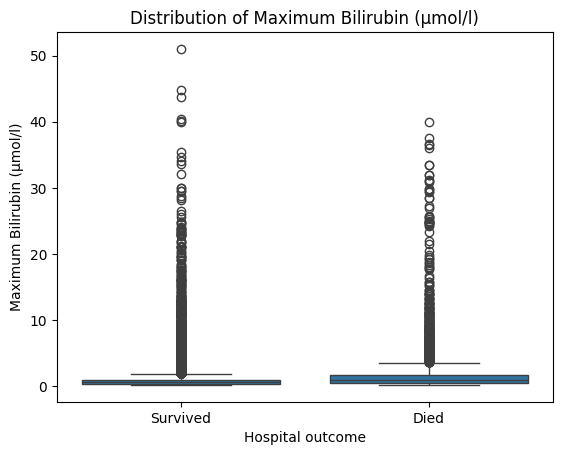

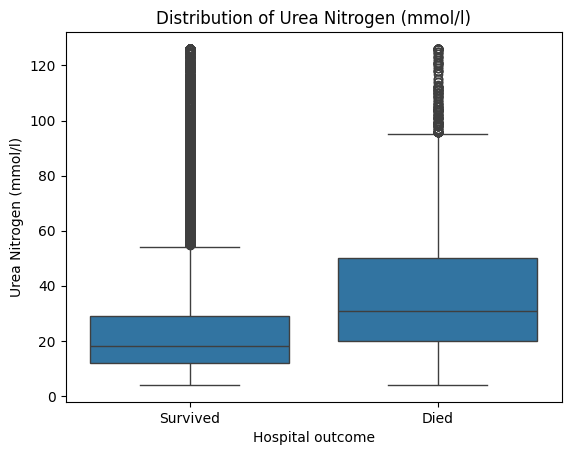

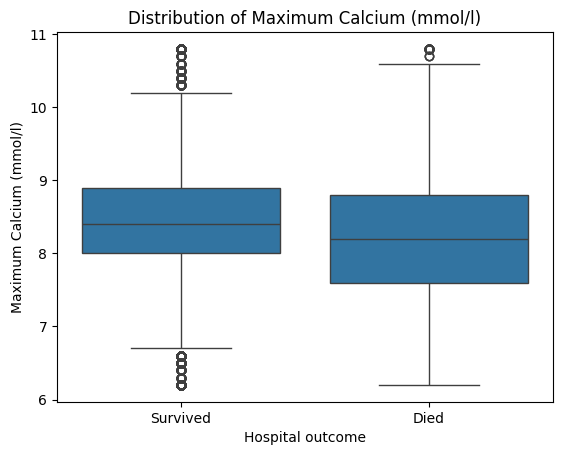

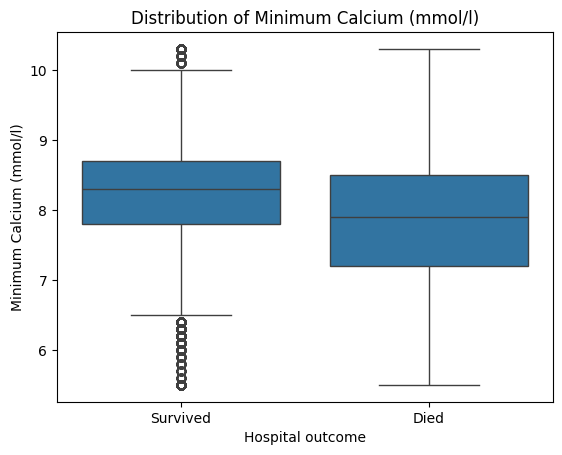

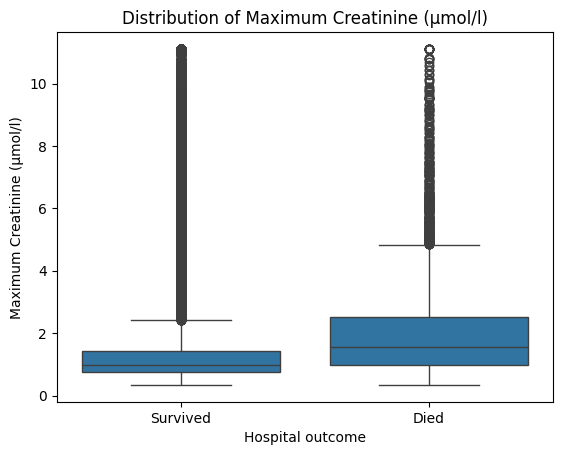

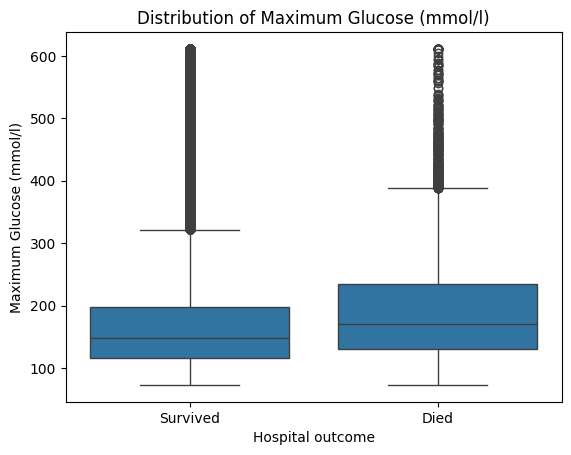

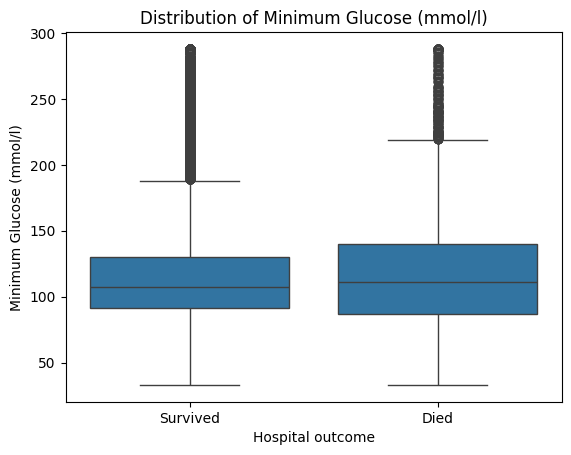

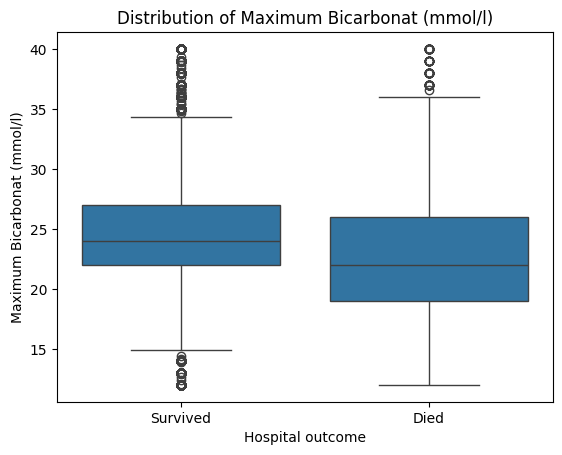

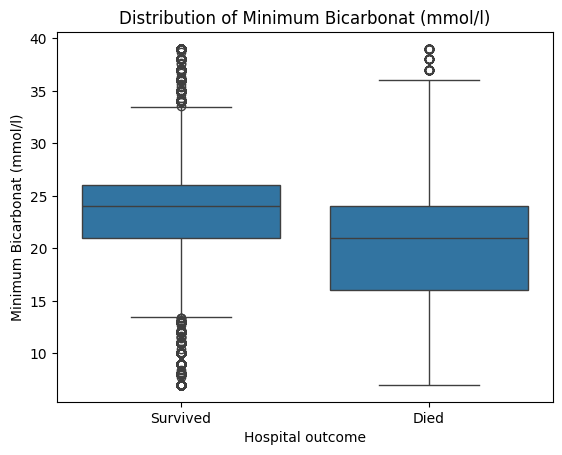

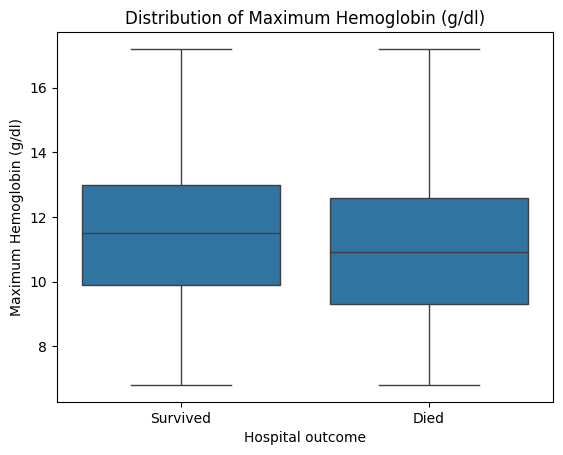

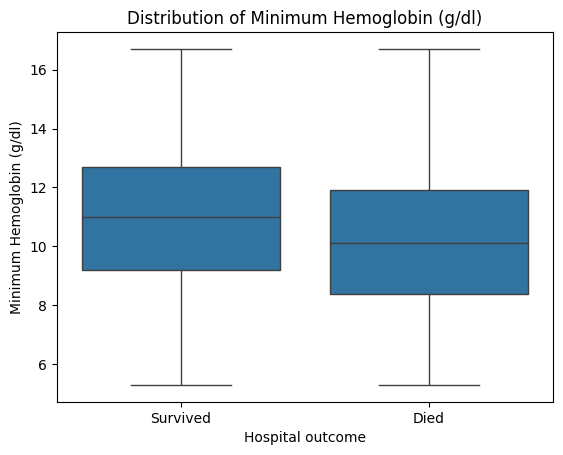

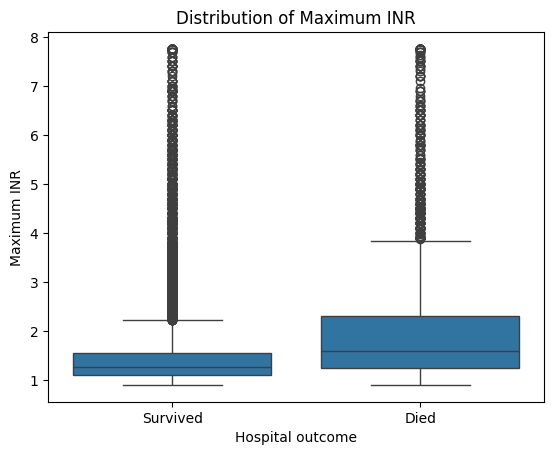

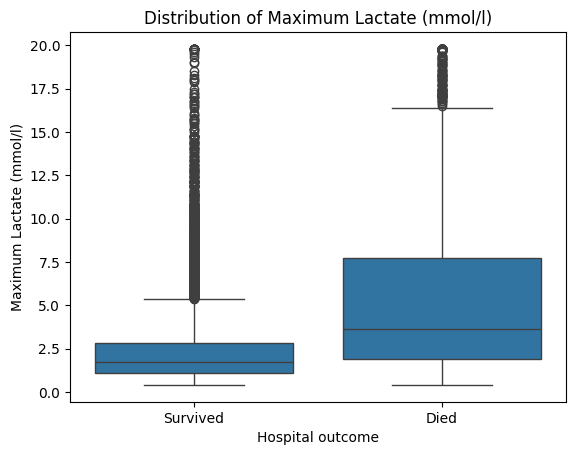

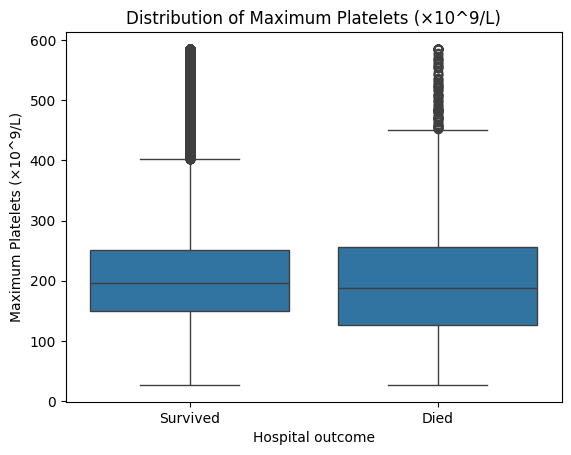

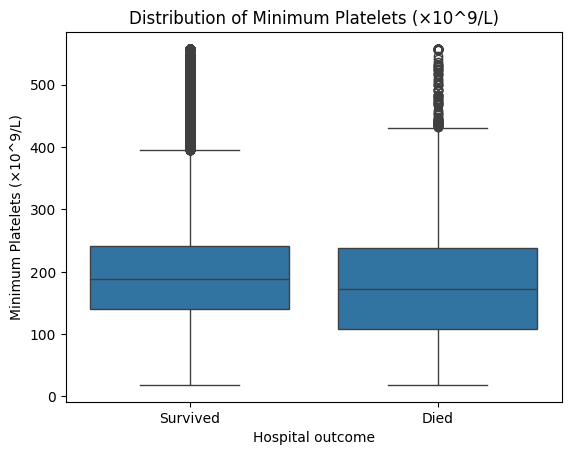

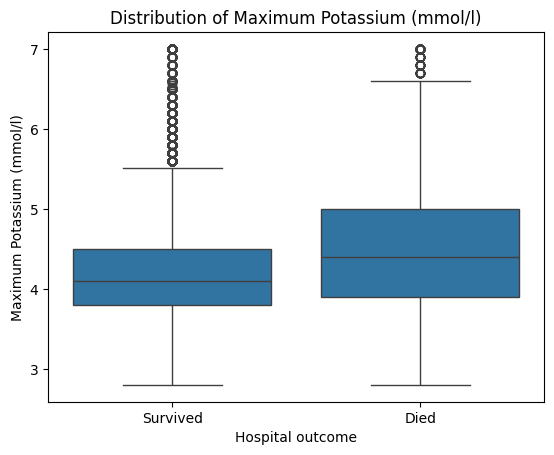

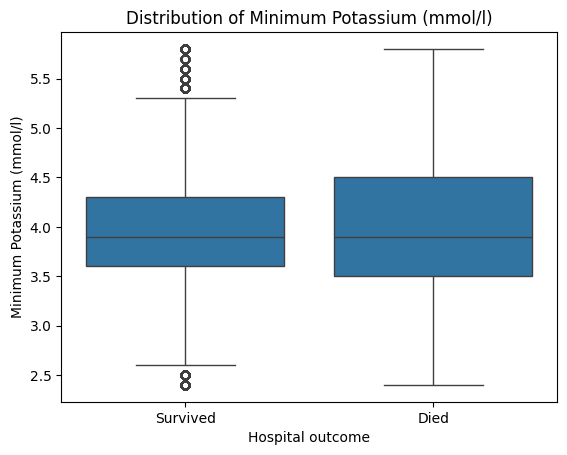

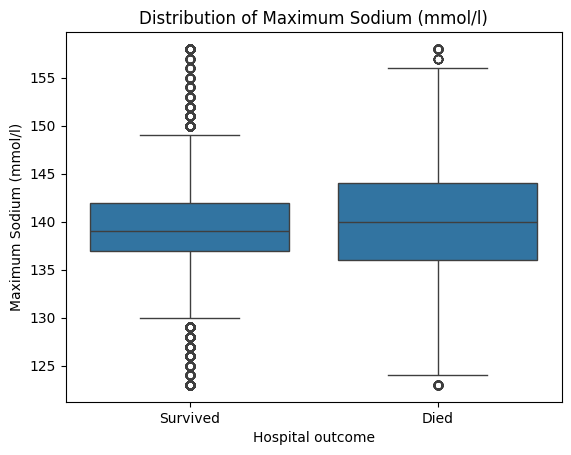

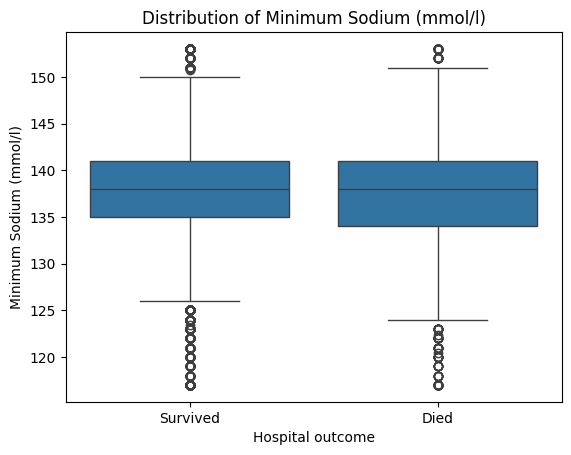

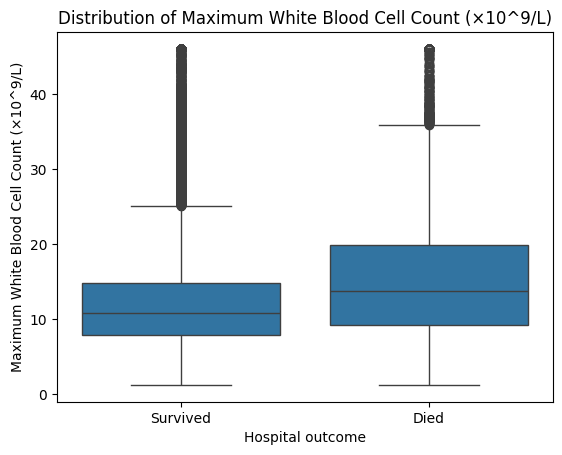

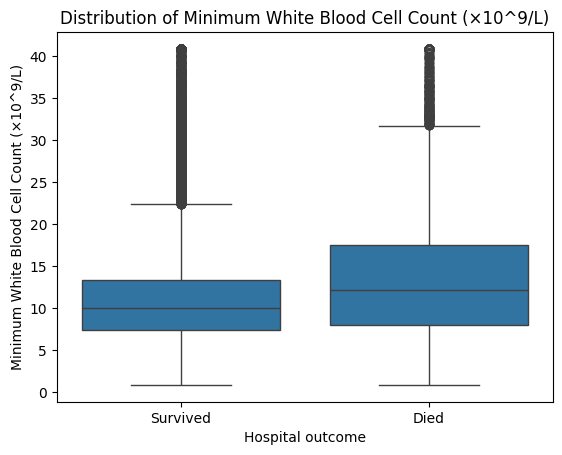

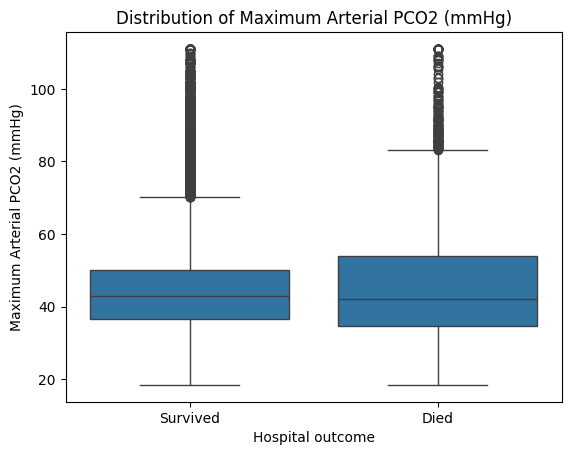

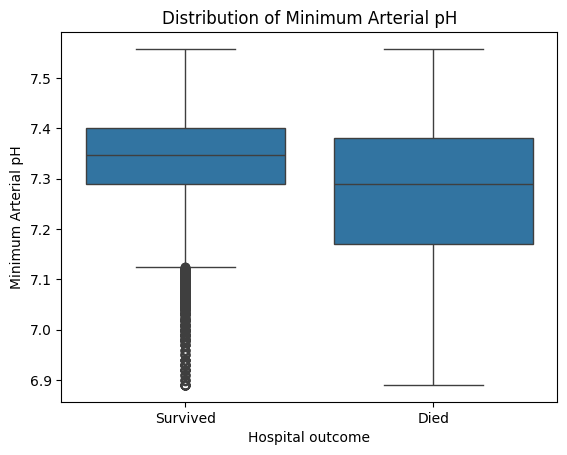

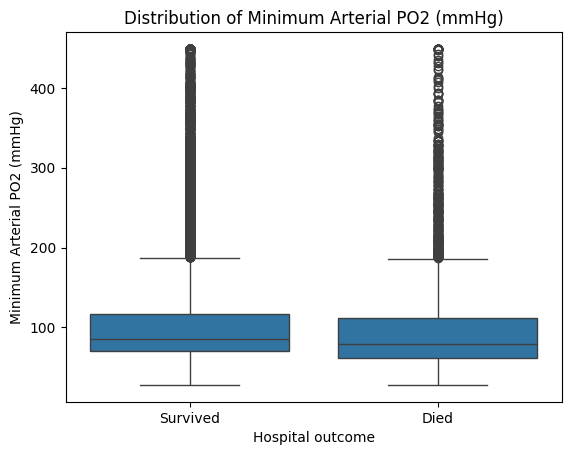

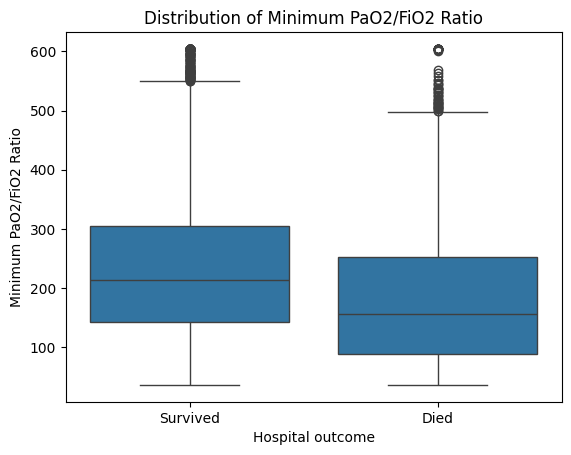

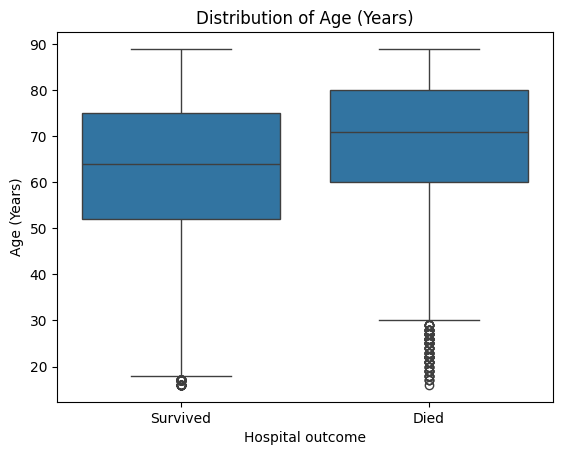

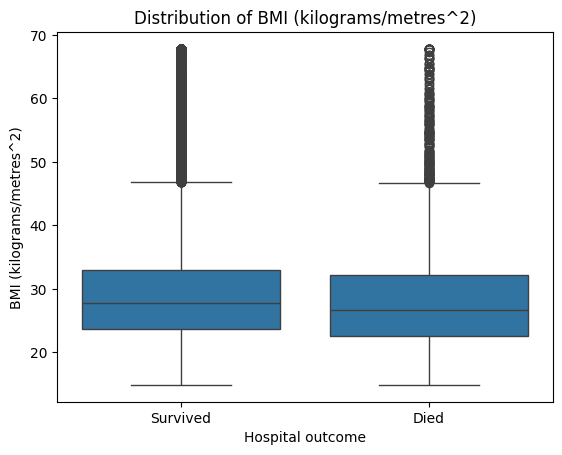

In [8]:
# ==================================================
# Univariate Analysis
# ==================================================

binary_vars = [
    col for col in clinical_vars
    if col not in ["gender", "ethnicity"]
]

def var_histograms(x):
  for feat in x:
    plt.figure()
    label = variable_labels.get(feat, feat)
    fig = sns.histplot(data=train_data, x=feat, bins=20, kde=True)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.show()
  return

var_histograms(d1_vars)
var_histograms(demographic_vars)

def var_boxplots(x):
  for feat in x:
    plt.figure()
    label = variable_labels.get(feat, feat)
    fig = sns.boxplot(data=train_data, x="hospital_death", y=feat)
    plt.title(f"Distribution of {label}")
    plt.xticks([0, 1], ["Survived", "Died"])
    plt.xlabel("Hospital outcome")
    plt.ylabel(label)
    plt.show()
  return

var_boxplots(d1_vars)
var_boxplots(demographic_vars)

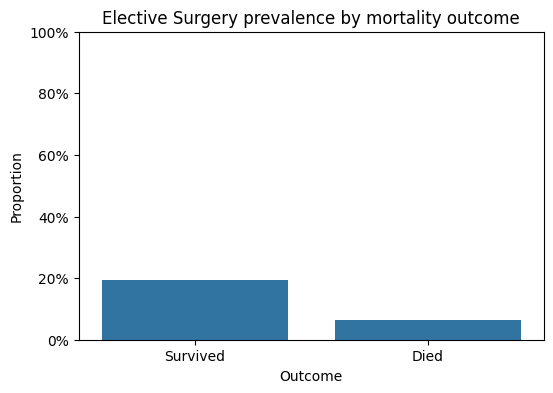

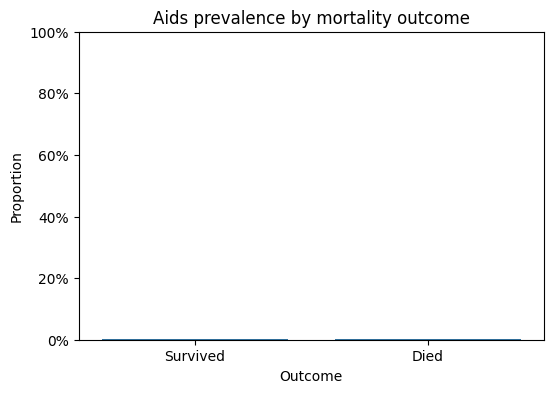

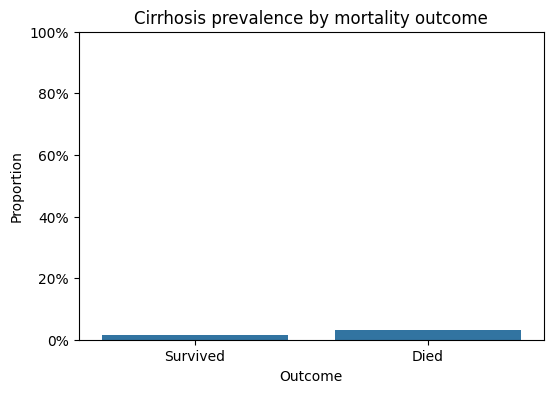

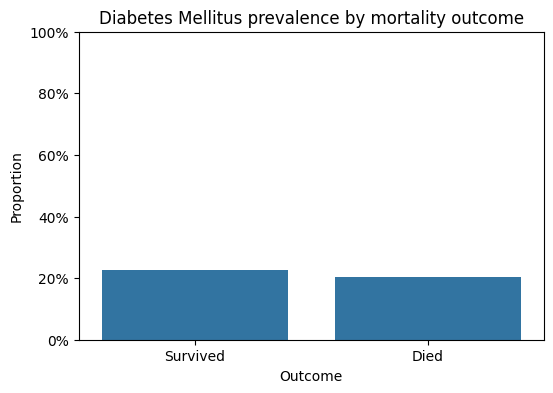

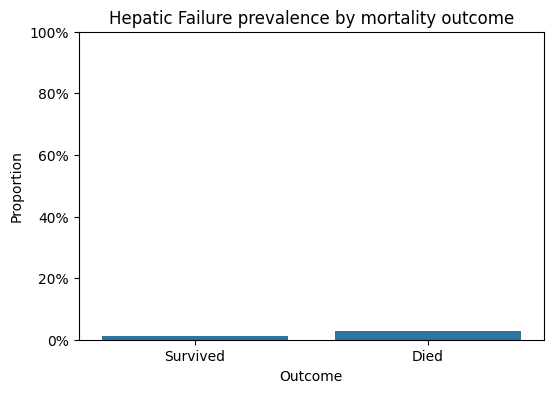

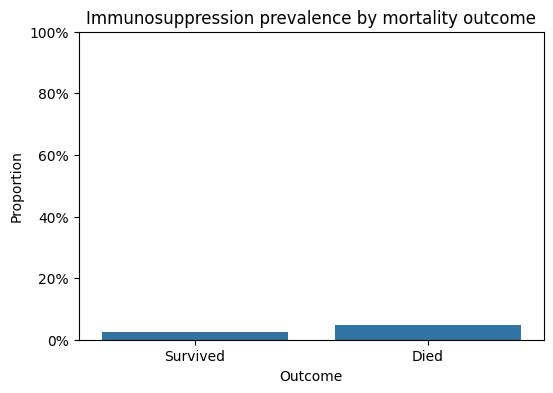

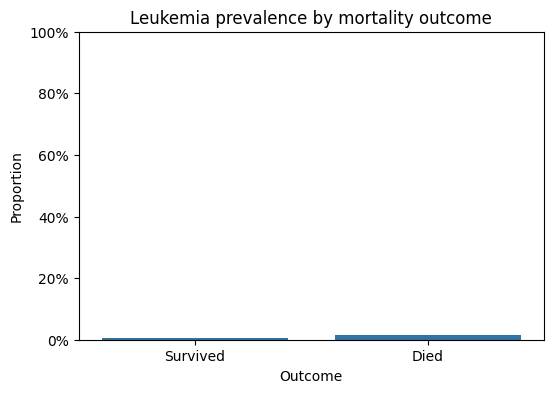

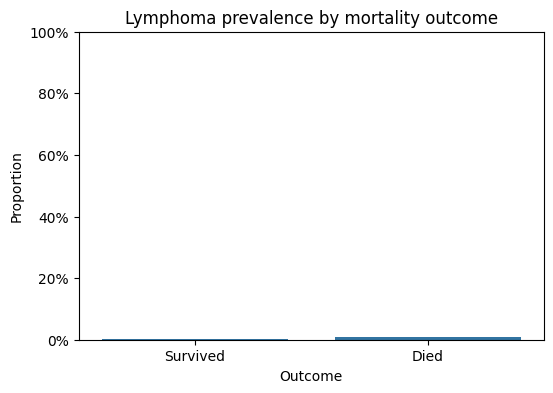

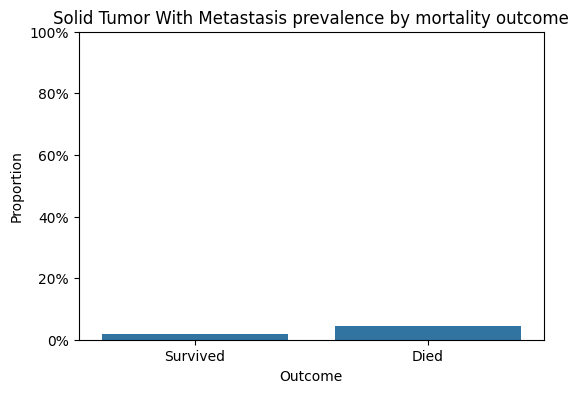

In [9]:
for feature in binary_vars:

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=train_data,
        x="hospital_death",
        y=feature,
        errorbar=None
    )

    plt.xticks(
        [0,1],
        ["Survived", "Died"]
    )

    plt.title(f"{feature.replace('_', ' ').title()} prevalence by mortality outcome")
    plt.xlabel("Outcome")
    plt.ylabel("Proportion")
    plt.ylim(0,1)
    plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

    plt.show()

## 4. Exploratory statistical comparisons

Welch tests compare means; Mann–Whitney tests compare ranks; chi-square tests examine categorical associations. Cohen’s d describes standardized mean differences. These are exploratory comparisons without multiple-testing adjustment, not an automatic feature-selection procedure.


In [10]:
# =========================
# Statistical Analysis
# =========================

death_patients = train_data[train_data["hospital_death"] == 1]
non_death_patients = train_data[train_data["hospital_death"] == 0]


def compare_groups(features, test_name="welch"):

    print(f"\n{'='*60}")
    print(f"{test_name.upper()} TEST")
    print(f"{'='*60}")

    for feature in features:
        label = variable_labels.get(feature, feature)
        group1 = death_patients[feature].dropna()
        group2 = non_death_patients[feature].dropna()

        if test_name == "welch":
            statistic, p_value = stats.ttest_ind(
                group1,
                group2,
                equal_var=False
            )

        elif test_name == "mannwhitney":
            statistic, p_value = stats.mannwhitneyu(
                group1,
                group2,
                alternative="two-sided"
            )

        print(
            f"{label:<20}"
            f"Statistic = {statistic:>10.2f}"
            f"   p = {p_value:.3e}"
        )
def compare_categorical(features):

    print(f"\n{'='*60}")
    print("CHI-SQUARE TEST")
    print(f"{'='*60}")

    for feature in features:
        label = variable_labels.get(feature, feature)
        table = pd.crosstab(
            train_data[feature],
            train_data["hospital_death"]
        )

        chi2, p_value, dof, expected = stats.chi2_contingency(table)

        print(
            f"{label:<25}"
            f"Chi2={chi2:>10.2f}"
            f" p={p_value:.3e}"
        )

def cohens_d(features):

    print(f"\n{'='*60}")
    print("Cohens D")
    print(f"{'='*60}")

    for feature in features:
      label = variable_labels.get(feature, feature)
      group1 = death_patients[feature].dropna()
      group2 = non_death_patients[feature].dropna()

      n1, n2 = len(group1), len(group2)
      var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

      # Pooled standard deviation
      pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

      # Cohen's d formula
      effect_size = (np.mean(group1) - np.mean(group2)) / pooled_std

      print(
            f"{label:<20}"
            f"Cohens D = {effect_size:>10.2f}"
        )

    return


compare_groups(d1_vars, test_name="welch")
compare_groups(d1_vars, test_name="mannwhitney")
compare_categorical(clinical_vars)
cohens_d(d1_vars)


WELCH TEST
Maximum Heartrate (bpm)Statistic =      39.29   p = 3.695e-306
Minimum Heartrate (bpm)Statistic =      -0.11   p = 9.145e-01
Maximum Mean Blood Pressure (mmHg)Statistic =      -3.95   p = 7.794e-05
Minimum Mean Blood Pressure (mmHg)Statistic =     -50.37   p = 0.000e+00
Maximum Respiratory Rate (breaths/min)Statistic =      25.93   p = 7.104e-142
Minimum Respiratory Rate (breaths/min)Statistic =       5.34   p = 9.590e-08
Minimum Blood Oxygen Saturation (%)Statistic =     -32.71   p = 1.541e-217
Maximum Systolic Blood Pressure (mmHg)Statistic =      -6.20   p = 6.056e-10
Minimum Systolic Blood Pressure (mmHg)Statistic =     -52.70   p = 0.000e+00
Maximum Temperature (°C)Statistic =       2.04   p = 4.180e-02
Minimum Temperature (°C)Statistic =     -31.04   p = 5.063e-197
Minimum Albumin (g/L)Statistic =     -37.01   p = 9.007e-263
Maximum Bilirubin (µmol/l)Statistic =      14.50   p = 2.376e-46
Urea Nitrogen (mmol/l)Statistic =      40.06   p = 0.000e+00
Maximum Calcium (mm

Missingness differed by mortality outcome, particularly for maximum day-one lactate: values were missing in 76.9% of survivors and 49.1% of non-survivors. Lactate availability was therefore associated with the outcome. Comparisons of observed lactate values describe a selected subset of patients and should be reported alongside the number of available observations. The reasons for missingness cannot be determined from this analysis alone.

In [11]:
summary = (
    train_data
    .groupby("hospital_death")[eda_vars]
    .agg(["count", "median", "min", "max"])
    .T
)

summary.columns = ["Survived", "Died"]
display(summary.round(2))

Survived     Died
age               count   64123.00  5803.00
                  median     64.00    71.00
                  min        16.00    16.00
                  max        89.00    89.00
d1_heartrate_max  count   66933.00  6318.00
                  median    100.00   114.00
                  min        58.00    58.00
                  max       177.00   177.00
d1_mbp_min        count   66885.00  6310.00
                  median     65.00    54.00
                  min        22.00    22.00
                  max       112.00   112.00
d1_spo2_min       count   66808.00  6293.00
                  median     93.00    90.00
                  min         0.00     0.00
                  max       100.00   100.00
d1_creatinine_max count   59597.00  5658.00
                  median      0.99     1.55
                  min         0.34     0.34
                  max        11.11    11.11
d1_lactate_max    count   15499.00  3225.00
                  median      1.70     3.60
                  min         0.40     0.40
                  max        19.80    19.80

In [12]:
quartiles = (
    train_data
    .groupby("hospital_death")[["d1_mbp_min", "d1_lactate_max"]]
    .quantile([0.25, 0.50, 0.75])
)
display(quartiles)

spo2_check = train_data.groupby("hospital_death")["d1_spo2_min"].agg(
    available_n="count",
    zero_n=lambda values: values.eq(0).sum()
)
spo2_check["zero_pct_of_available"] = (
    100 * spo2_check["zero_n"] / spo2_check["available_n"]
)
display(spo2_check.round(2))

d1_mbp_min  d1_lactate_max
hospital_death                                 
0              0.25        56.0             1.1
               0.50        65.0             1.7
               0.75        75.0             2.8
1              0.25        44.0             1.9
               0.50        54.0             3.6
               0.75        65.0             7.7

,available_n,zero_n,zero_pct_of_available
hospital_death,,,
0,66808,91,0.14
1,6293,38,0.60


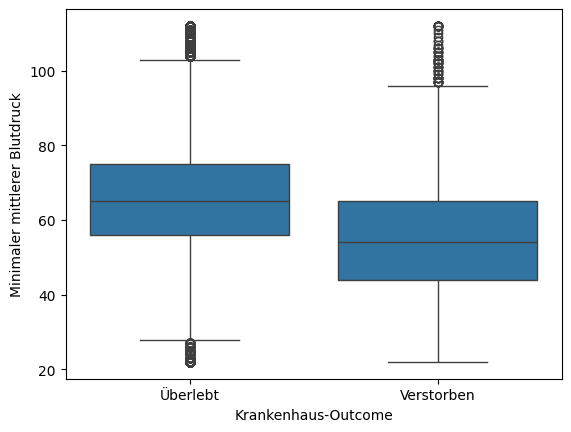

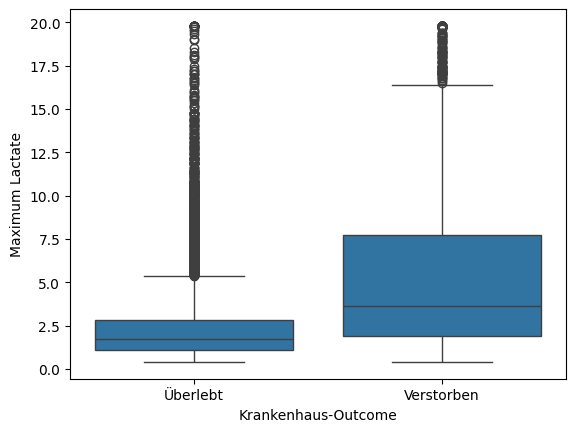

In [13]:
sns.boxplot(
    data=train_data,
    x="hospital_death",
    y="d1_mbp_min"
)

plt.xticks([0, 1], ["Überlebt", "Verstorben"])
plt.xlabel("Krankenhaus-Outcome")
plt.ylabel("Minimaler mittlerer Blutdruck")
plt.show()

sns.boxplot(
    data=train_data,
    x="hospital_death",
    y="d1_lactate_max"
)

plt.xticks([0, 1], ["Überlebt", "Verstorben"])
plt.xlabel("Krankenhaus-Outcome")
plt.ylabel("Maximum Lactate")
plt.show()

Patients who died in hospital had a lower median minimum day-one mean blood pressure and a higher median maximum day-one lactate than survivors. The distributions overlapped, so neither variable alone clearly separated the two groups. Lactate results should be interpreted cautiously because values were missing for many patients, particularly survivors.

Statistical comparisons identified differences between survivors and non-survivors across several variables. Minimum day-one mean blood pressure was lower among non-survivors (Cohen’s d = −0.71), while maximum day-one lactate was higher (d = 1.12).

Many p-values were very small, but statistical significance did not always indicate a substantial difference. For example, maximum mean blood pressure had a small effect size (d = −0.06) despite a statistically significant Welch test.

These results are exploratory and do not establish causation or predictive performance. Lactate findings apply only to patients with available measurements, and missingness differed between outcome groups. Multiple comparisons were performed without adjustment.

## 5. Preprocessing

Numeric features use median imputation and scaling; text features use most-frequent imputation and one-hot encoding. Preprocessing is fitted within each training fold. Scaling is retained for a common workflow, although trees do not require it.


In [14]:
total_vars = clinical_vars + d1_vars + demographic_vars

X_train = train_data[total_vars].copy()
y_train = train_data["hospital_death"].copy()

X_test = test_data[total_vars].copy()
y_test = test_data["hospital_death"].copy()

categorical_cols = ["gender", "ethnicity"]

numeric_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print(X_train[categorical_cols].dtypes)
print(X_train[numeric_cols].dtypes)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

gender       object
ethnicity    object
dtype: object
elective_surgery                 int64
aids                           float64
cirrhosis                      float64
diabetes_mellitus              float64
hepatic_failure                float64
immunosuppression              float64
leukemia                       float64
lymphoma                       float64
solid_tumor_with_metastasis    float64
d1_heartrate_max               float64
d1_heartrate_min               float64
d1_mbp_max                     float64
d1_mbp_min                     float64
d1_resprate_max                float64
d1_resprate_min                float64
d1_spo2_min                    float64
d1_sysbp_max                   float64
d1_sysbp_min                   float64
d1_temp_max                    float64
d1_temp_min                    float64
d1_albumin_min                 float64
d1_bilirubin_max               float64
d1_bun_max                     float64
d1_calcium_max                 float64
d1_calcium

##5. Dummy baseline

Five-fold stratified cross-validation provides predictions for each training case from a model that did not train on that case. The dummy predicts the majority class. Undefined positive-class precision is reported as zero.


              precision    recall  f1-score   support

           0       0.91      1.00      0.95     67038
           1       0.00      0.00      0.00      6332

    accuracy                           0.91     73370
   macro avg       0.46      0.50      0.48     73370
weighted avg       0.83      0.91      0.87     73370



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


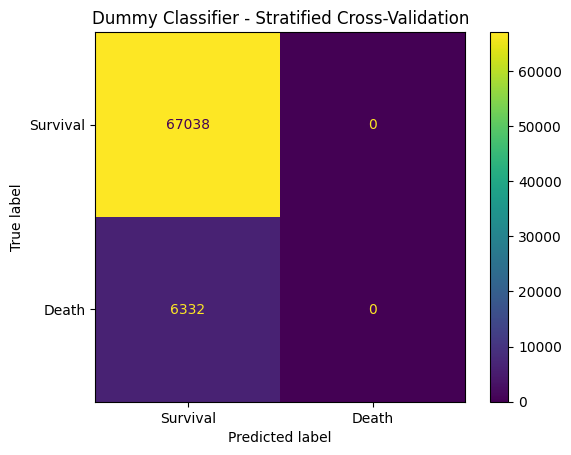

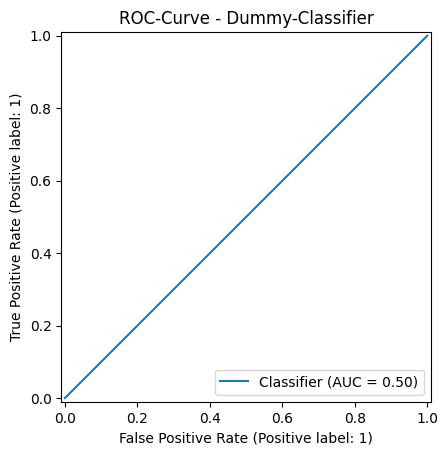

ROC-AUC: 0.500


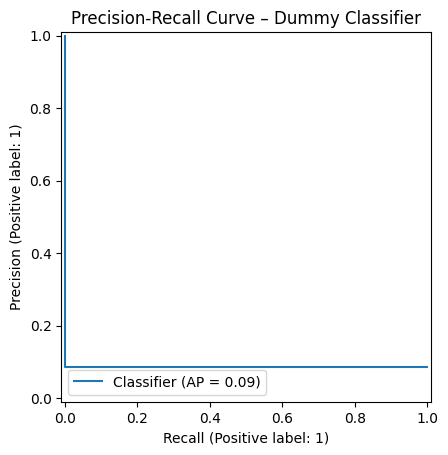

Average Precision: 0.086


In [15]:
# Define the cross-validation splitter
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dummy_model = DummyClassifier(strategy="prior")
dummy_pred = cross_val_predict(dummy_model, X_train, y_train, cv=cv, method="predict")
dummy_prob = cross_val_predict(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

#Classification Report
print(classification_report(y_train, dummy_pred))

#Confusion Matrix
cm = confusion_matrix(y_train, dummy_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot()
plt.title("Dummy Classifier - Stratified Cross-Validation")
plt.show()

#ROC Curve using probabilities
RocCurveDisplay.from_predictions(y_train, dummy_prob)
plt.title("ROC-Curve - Dummy-Classifier")
plt.show()

dummy_roc_auc = roc_auc_score(y_train, dummy_prob)
print(f"ROC-AUC: {dummy_roc_auc:.3f}")

PrecisionRecallDisplay.from_predictions(
    y_train,
    dummy_prob
)

plt.title("Precision-Recall Curve – Dummy Classifier")
plt.show()

dummy_average_precision = average_precision_score(
    y_train,
    dummy_prob
)

print(
    "Average Precision:",
    f"{dummy_average_precision:.3f}"
)

### 6. Logistic regression

Class weighting is set to `balanced`. Classification metrics use a threshold of 0.5.


              precision    recall  f1-score   support

           0       0.97      0.79      0.87     67038
           1       0.25      0.73      0.37      6332

    accuracy                           0.78     73370
   macro avg       0.61      0.76      0.62     73370
weighted avg       0.91      0.78      0.83     73370



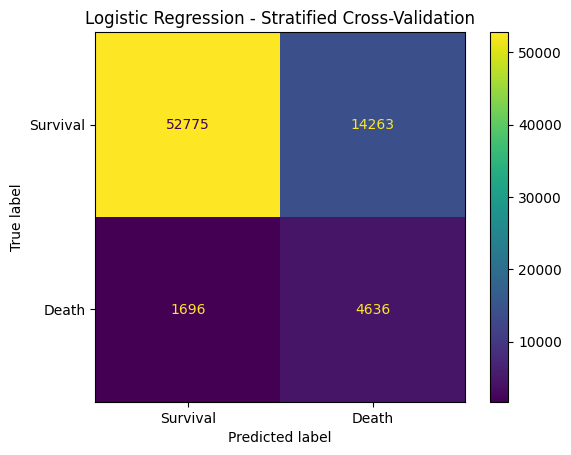

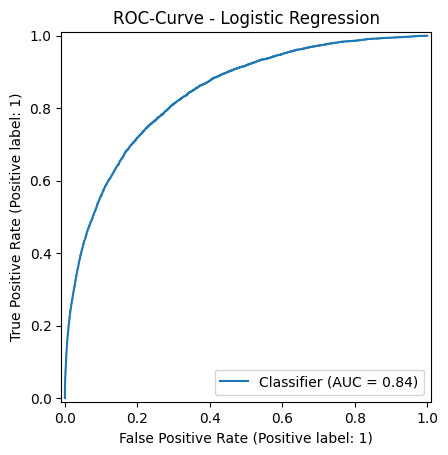

ROC-AUC: 0.841


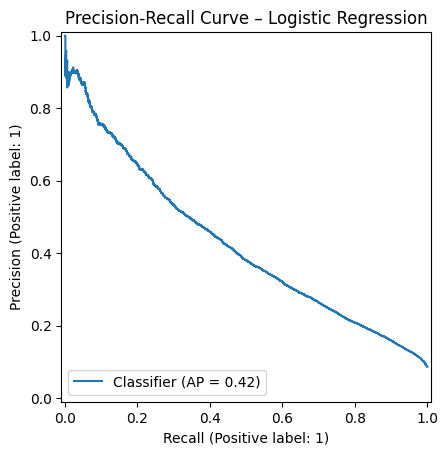

Average Precision: 0.424


In [16]:
# Logistic Regression

balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

# Predictions

lgr_prob = cross_val_predict(
    balanced_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

lgr_pred = (lgr_prob >= 0.5).astype(int)

# Classification Report

print(classification_report(y_train, lgr_pred))

# Confusion Matrix

cm = confusion_matrix(y_train, lgr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot()
plt.title("Logistic Regression - Stratified Cross-Validation")
plt.show()

# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y_train, lgr_prob) # Use probabilities for ROC curve
plt.title("ROC-Curve - Logistic Regression")
plt.show()

lgr_roc_auc = roc_auc_score(y_train, lgr_prob)
print(f"ROC-AUC: {lgr_roc_auc:.3f}")

# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y_train,
    lgr_prob
)

plt.title("Precision-Recall Curve – Logistic Regression")
plt.show()

lgr_average_precision = average_precision_score(
    y_train,
    lgr_prob
)

print(
    "Average Precision:",
    f"{lgr_average_precision:.3f}"
)

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     16760
           1       0.25      0.74      0.37      1583

    accuracy                           0.79     18343
   macro avg       0.61      0.76      0.62     18343
weighted avg       0.91      0.79      0.83     18343

Test ROC-AUC: 0.8504884460037058


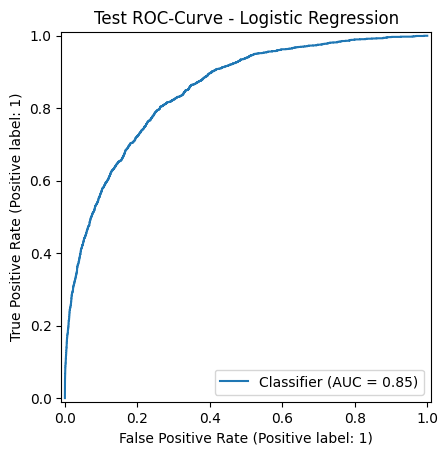

Test ROC-AUC: 0.850


In [17]:
# Fit on all training data
balanced_pipeline.fit(X_train, y_train)

# Predict on test data
test_prob = balanced_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

# Compare predictions with test outcomes
print(classification_report(y_test, test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, test_prob))

# ROC Curve and ROC-AUC
RocCurveDisplay.from_predictions(y_test, test_prob) # Use probabilities for ROC curve
plt.title("Test ROC-Curve - Logistic Regression")
plt.show()

test_roc_auc = roc_auc_score(y_test, test_prob)
print(f"Test ROC-AUC: {test_roc_auc:.3f}")

The logistic regression pipeline was fitted on the full training set and evaluated on the held-out test set. It achieved a test ROC-AUC of approximately 0.85, similar to the cross-validation result of 0.841.

At a classification threshold of 0.5, the model identified approximately 74% of patients who died in hospital (recall = 0.74). However, only 25% of patients predicted to die actually died (precision = 0.25), indicating many false positives.

Unlike the dummy classifier, which predicted survival for every patient, logistic regression identified a substantial proportion of deaths. These results provide a useful learning baseline, but do not establish clinical suitability. The full dataset had been explored before the split, and performance on unseen hospitals remains untested.

##7. Random forest

Fixed settings: 100 trees, maximum depth 10, minimum leaf size 5, and balanced class weights. No parameter search was performed.


              precision    recall  f1-score   support

           0       0.96      0.89      0.92     67038
           1       0.34      0.62      0.44      6332

    accuracy                           0.87     73370
   macro avg       0.65      0.75      0.68     73370
weighted avg       0.91      0.87      0.88     73370



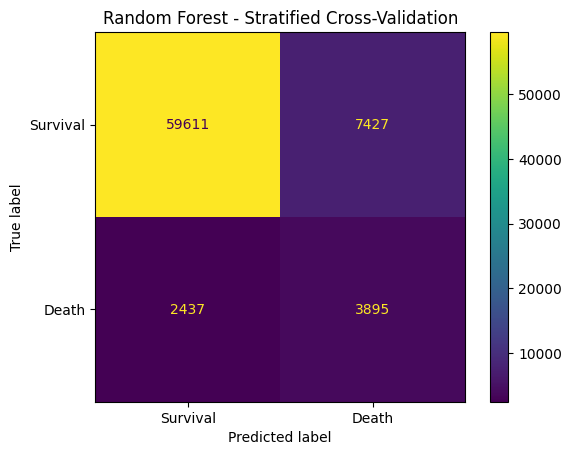

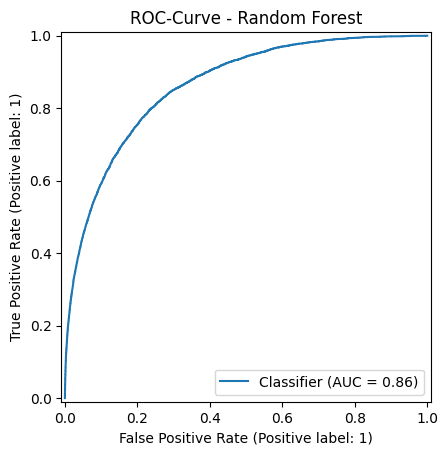

ROC-AUC: 0.863


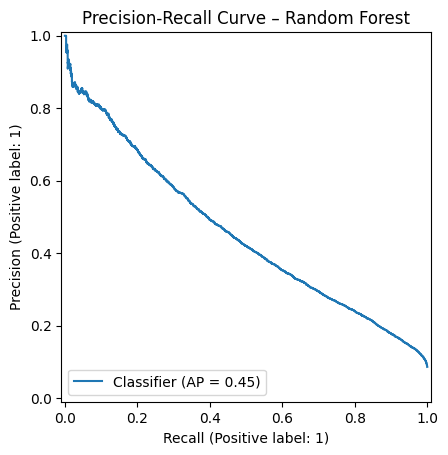

Average Precision: 0.455


In [18]:
# Random Forrest

rf_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Predictions
rf_prob = cross_val_predict(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

rf_pred = (rf_prob >= 0.5).astype(int)

# Classification Report

print(classification_report(y_train, rf_pred))

# Confusion Matrix

cm = confusion_matrix(y_train, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot(values_format="d")
plt.title("Random Forest - Stratified Cross-Validation")
plt.show()

# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y_train, rf_prob) # Use probabilities for ROC curve
plt.title("ROC-Curve - Random Forest")
plt.show()

rf_roc_auc = roc_auc_score(y_train, rf_prob)
print(f"ROC-AUC: {rf_roc_auc:.3f}")

# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y_train,
    rf_prob
)

plt.title("Precision-Recall Curve – Random Forest")
plt.show()

rf_average_precision = average_precision_score(
    y_train,
    rf_prob
)

print(
    "Average Precision:",
    f"{rf_average_precision:.3f}"
)

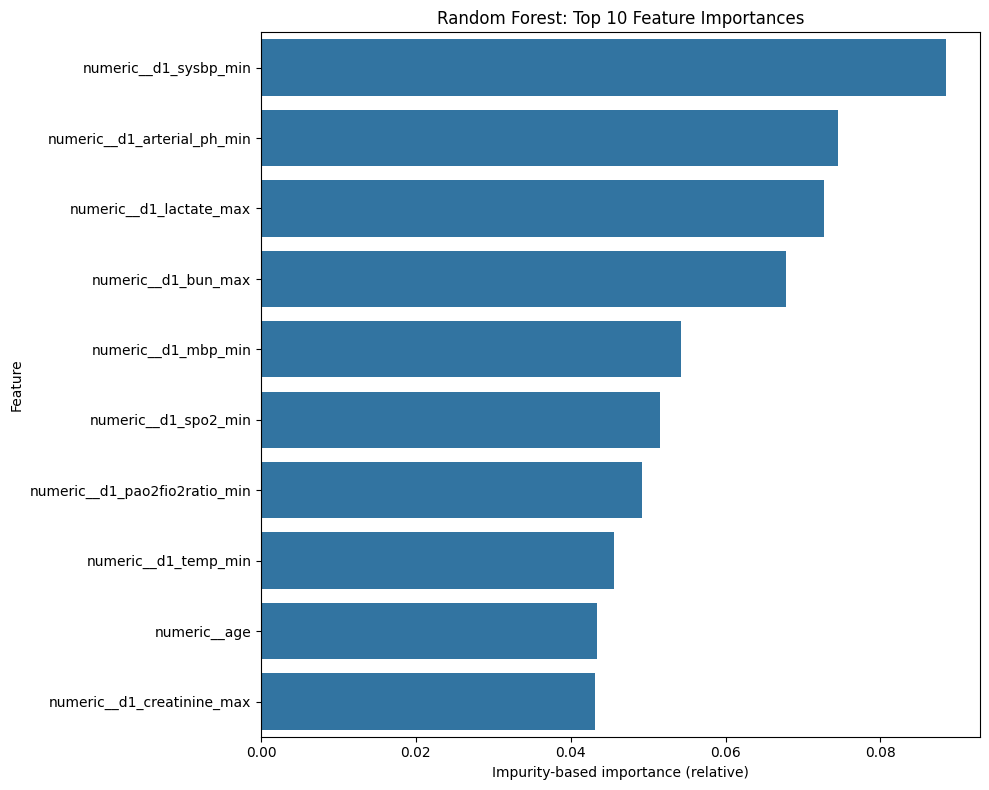

In [19]:
rf_pipeline.fit(X_train, y_train)

# Feature names after preprocessing
feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Importances from the fitted random forest
importances = (
    rf_pipeline.named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

def plot_importance(feature_importance_df, top_n=10):
    """
    Plots the top N feature importances.
    """
    plt.figure(figsize=(10, 8))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=feature_importance_df.head(top_n)
    )
    plt.title(f"Random Forest: Top {top_n} Feature Importances")
    plt.xlabel("Impurity-based importance (relative)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

plot_importance(feature_importance)

In [20]:
rf_test_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_test_pred = (rf_test_prob >= 0.5).astype(int)

print(classification_report(y_test, rf_test_pred))

print("Test ROC-AUC:",
      round(roc_auc_score(y_test, rf_test_prob), 3))

print("Test Average Precision:",
      round(average_precision_score(y_test, rf_test_prob), 3))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92     16760
           1       0.34      0.64      0.44      1583

    accuracy                           0.86     18343
   macro avg       0.65      0.76      0.68     18343
weighted avg       0.91      0.86      0.88     18343

Test ROC-AUC: 0.867
Test Average Precision: 0.471


Minimum day-one systolic blood pressure had the highest feature importance in the random forest, followed by minimum arterial pH and maximum lactate. These variables contributed strongly to the model’s tree splits. Feature importance does not indicate the direction of an association or establish causation. The findings also depend on preprocessing, including the imputation of missing values.

##8. XGBoost

Fixed settings: 100 trees, depth 3 and learning rate 0.1. No additional class weighting is used. Differences from other models therefore reflect both algorithm and configuration.


              precision    recall  f1-score   support

           0       0.93      0.99      0.96     67038
           1       0.72      0.24      0.36      6332

    accuracy                           0.93     73370
   macro avg       0.82      0.62      0.66     73370
weighted avg       0.91      0.93      0.91     73370



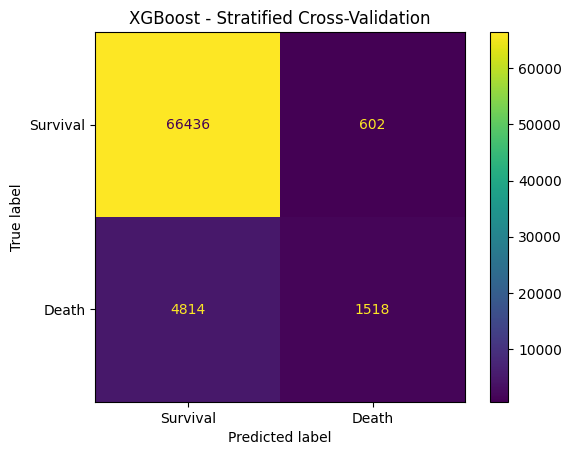

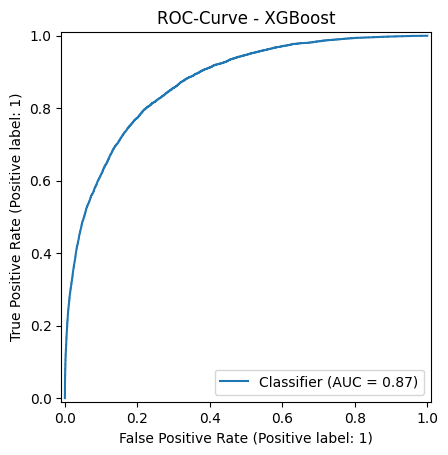

ROC-AUC: 0.872


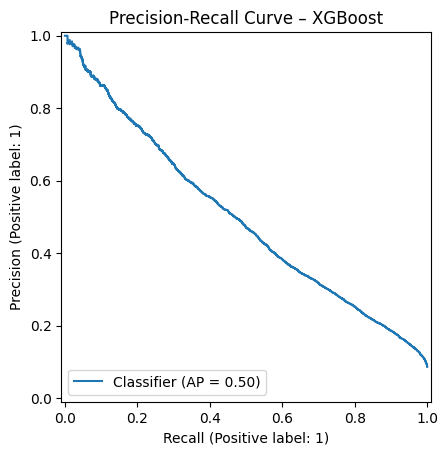

Average Precision: 0.497


In [21]:
# XGBoost

xgb_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=2
    ))
])

# Predictions
xgb_prob = cross_val_predict(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

xgb_pred = (xgb_prob >= 0.5).astype(int)

# Classification Report

print(classification_report(y_train, xgb_pred))

# Confusion Matrix

cm = confusion_matrix(y_train, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot()
plt.title("XGBoost - Stratified Cross-Validation")
plt.show()

# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y_train, xgb_prob) # Use probabilities for ROC curve
plt.title("ROC-Curve - XGBoost")
plt.show()

xgb_roc_auc = roc_auc_score(y_train, xgb_prob)
print(f"ROC-AUC: {xgb_roc_auc:.3f}")

# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y_train,
    xgb_prob
)

plt.title("Precision-Recall Curve – XGBoost")
plt.show()

xgb_average_precision = average_precision_score(
    y_train,
    xgb_prob
)

print(
    "Average Precision:",
    f"{xgb_average_precision:.3f}"
)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     67038
           1       0.55      0.40      0.47      6332

    accuracy                           0.92     73370
   macro avg       0.75      0.69      0.71     73370
weighted avg       0.91      0.92      0.91     73370



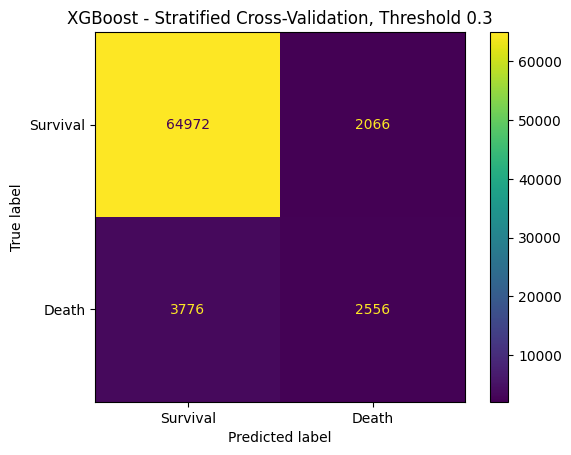

In [22]:
xgb_pred_03 = (xgb_prob >= 0.3).astype(int)

# Classification Report

print(classification_report(y_train, xgb_pred_03))

# Confusion Matrix

cm = confusion_matrix(y_train, xgb_pred_03)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survival", "Death"])
disp.plot()
plt.title("XGBoost - Stratified Cross-Validation, Threshold 0.3")
plt.show()

Lowering the XGBoost classification threshold from 0.5 to 0.3 increased recall for in-hospital deaths from 0.24 to 0.40, while precision decreased from 0.72 to 0.55. This identified 1,038 additional deaths but produced 1,464 additional false positives. ROC-AUC and average precision remained unchanged because the underlying predicted scores were unchanged. The threshold of 0.3 was explored as an example and was not established as optimal.

In [23]:
# Fit on all training data
xgb_pipeline.fit(X_train, y_train)

# Predict on test data
xgb_test_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.3]:
    xgb_test_pred = (xgb_test_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, xgb_test_pred))

print("Test ROC-AUC:",
      round(roc_auc_score(y_test, xgb_test_prob), 3))

print("Test Average Precision:",
      round(average_precision_score(y_test, xgb_test_prob), 3))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     16760
           1       0.74      0.25      0.37      1583

    accuracy                           0.93     18343
   macro avg       0.84      0.62      0.67     18343
weighted avg       0.92      0.93      0.91     18343


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     16760
           1       0.57      0.42      0.48      1583

    accuracy                           0.92     18343
   macro avg       0.76      0.70      0.72     18343
weighted avg       0.91      0.92      0.92     18343

Test ROC-AUC: 0.879
Test Average Precision: 0.527


## 9. Model comparison

The first table uses out-of-fold predictions from the training set. Thresholds are stated explicitly; counts per 100 refer to encounters.

In [24]:
# MODEL-SUMMARY FUNCTION

def summarize_model(
    model_name,
    y_true,
    y_pred,
    y_prob,
    threshold=0.5
):
    """
    Summarize threshold-independent and threshold-dependent
    model performance using out-of-fold predictions.
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Model": model_name,

        # Threshold-independent discrimination
        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "Average_Precision": average_precision_score(
            y_true,
            y_prob
        ),

        # Metrics at the default threshold of 0.5
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Death_Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Death_Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Death_F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Specificity": specificity,

        # Confusion-matrix counts
        "True_Positives": tp,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Negatives": tn,

        # Approximate predicted deaths per 100 encounters
        "Predicted_deaths_per_100_encounters": (
            y_pred.mean() * 100
        ),
        "False_positives_per_100_encounters": (
            fp / len(y_true) * 100
        ),

        "Threshold": threshold
    }

# MODEL-COMPARISON TABLE

model_comparison = pd.DataFrame([
    summarize_model(
        model_name="Dummy classifier",
        y_true=y_train,
        y_pred=dummy_pred,
        y_prob=dummy_prob
    ),
    summarize_model(
        model_name="Logistic Regression",
        y_true=y_train,
        y_pred=lgr_pred,
        y_prob=lgr_prob
    ),
    summarize_model(
        model_name="Random Forest",
        y_true=y_train,
        y_pred=rf_pred,
        y_prob=rf_prob
    ),
    summarize_model(
        model_name="XGBoost",
        y_true=y_train,
        y_pred=xgb_pred,
        y_prob=xgb_prob
    ),

    summarize_model(
        model_name="XGBoost",
        y_true=y_train,
        y_pred=xgb_pred_03,
        y_prob=xgb_prob,
        threshold=0.3
    )
])

display(
    model_comparison.round(3)
)


# COMPACT PORTFOLIO TABLE

comparison_columns = [
    "Model",
    "ROC_AUC",
    "Average_Precision",
    "Death_Precision",
    "Death_Recall",
    "Death_F1",
    "Specificity",
    "Predicted_deaths_per_100_encounters",
    "False_positives_per_100_encounters",
    "Threshold"
]

model_comparison_compact = (
    model_comparison[
        comparison_columns
    ]
    .round(3)
)

display(
    model_comparison_compact
)

,Model,ROC_AUC,Average_Precision,Accuracy,Death_Precision,Death_Recall,Death_F1,Specificity,True_Positives,False_Positives,False_Negatives,True_Negatives,Predicted_deaths_per_100_encounters,False_positives_per_100_encounters,Threshold
0,Dummy classifier,0.500,0.086,0.914,0.000,0.000,0.000,1.000,0,0,6332,67038,0.000,0.000,0.5
1,Logistic Regression,0.841,0.424,0.782,0.245,0.732,0.367,0.787,4636,14263,1696,52775,25.758,19.440,0.5
2,Random Forest,0.863,0.455,0.866,0.344,0.615,0.441,0.889,3895,7427,2437,59611,15.431,10.123,0.5
3,XGBoost,0.872,0.497,0.926,0.716,0.240,0.359,0.991,1518,602,4814,66436,2.889,0.820,0.5
4,XGBoost,0.872,0.497,0.920,0.553,0.404,0.467,0.969,2556,2066,3776,64972,6.300,2.816,0.3


,Model,ROC_AUC,Average_Precision,Death_Precision,Death_Recall,Death_F1,Specificity,Predicted_deaths_per_100_encounters,False_positives_per_100_encounters,Threshold
0,Dummy classifier,0.500,0.086,0.000,0.000,0.000,1.000,0.000,0.000,0.5
1,Logistic Regression,0.841,0.424,0.245,0.732,0.367,0.787,25.758,19.440,0.5
2,Random Forest,0.863,0.455,0.344,0.615,0.441,0.889,15.431,10.123,0.5
3,XGBoost,0.872,0.497,0.716,0.240,0.359,0.991,2.889,0.820,0.5
4,XGBoost,0.872,0.497,0.553,0.404,0.467,0.969,6.300,2.816,0.3


### Test-set summary

These are descriptive results for the fixed configurations. XGBoost at 0.3 is an illustrative threshold, not a clinically selected cutoff.


In [25]:
test_comparison = pd.DataFrame([
    summarize_model("Logistic Regression", y_test, test_pred, test_prob),
    summarize_model("Random Forest", y_test, rf_test_pred, rf_test_prob),
    summarize_model("XGBoost", y_test, (xgb_test_prob >= 0.5).astype(int), xgb_test_prob, 0.5),
    summarize_model("XGBoost", y_test, (xgb_test_prob >= 0.3).astype(int), xgb_test_prob, 0.3)
])
display(test_comparison[comparison_columns].round(3))


,Model,ROC_AUC,Average_Precision,Death_Precision,Death_Recall,Death_F1,Specificity,Predicted_deaths_per_100_encounters,False_positives_per_100_encounters,Threshold
0,Logistic Regression,0.850,0.445,0.249,0.738,0.372,0.790,25.579,19.212,0.5
1,Random Forest,0.867,0.471,0.335,0.645,0.441,0.879,16.611,11.045,0.5
2,XGBoost,0.879,0.527,0.744,0.250,0.374,0.992,2.895,0.741,0.5
3,XGBoost,0.879,0.527,0.567,0.423,0.485,0.970,6.438,2.786,0.3


### Conclusion

Among the evaluated configurations, XGBoost achieved the highest cross-validation ROC-AUC (0.872) and average precision (0.497). Logistic regression identified the largest proportion of deaths at the examined thresholds, but produced more false positives. Lowering the XGBoost threshold increased recall while reducing precision.

Test-set results were similar to cross-validation results. However, these findings do not establish clinical suitability. Missed deaths and false-positive predictions represent different potential consequences, whose importance depends on the intended use. Performance on unseen hospitals and the impact on clinical decisions were not evaluated.

This project demonstrates an end-to-end learning workflow for ICU mortality prediction, including exploratory analysis, preprocessing, model comparison and threshold analysis. The initial exploration included the full dataset, which limits the independence of the subsequent test evaluation.

### Limitations and learning outcomes

- First-day measurements do not support a prediction at ICU admission.
- Missingness differs by outcome, especially for lactate. Median/mode imputation is a simple baseline, not a resolution of the missing-data mechanism.
- Initial exploration used the full dataset. The random split does not test generalization to unseen hospitals.
- Class weighting differs between models. Thresholds of 0.5 and 0.3 are illustrative; probability calibration and clinical utility were not evaluated.
- Impurity-based importance can favor variables with many candidate split points and is affected by correlated features. It does not establish direction or causation.

The main learning outcomes are leakage-aware preprocessing, comparison against a dummy baseline, interpretation of imbalanced-class metrics, and understanding the precision–recall trade-off. No clinical deployment claim is made.